# N01 - Beyond-RWA Mediated Interactions

## Exchange, qubit-pair processes, conditional oscillator squeezing, and reconstruction with QuTiP 5

## James--Jerke filtering, signed-harmonic completion, Schrieffer--Wolff reconstruction, and virtual paths

This notebook is a guided route from the microscopic two-qubit Rabi Hamiltonian to controlled second-order predictions. It is designed for a graduate lecture, self-study, or adaptation to a related cavity- or circuit-QED problem.

The central diagnostic question is

> **How can an approximation reproduce plausible qubit exchange while missing an entire physical sector?**

We compare four descriptions:

1. the microscopic two-qubit Rabi model;
2. the complete second-order Schrieffer--Wolff (SW) transformed model with encoding and reconstruction;
3. a deliberately secularized beyond-RWA diagnostic model that retains corrected shifts and ordinary exchange but removes anomalous dynamics;
4. the ordinary dispersive Jaynes--Cummings (JC) model.

James--Jerke filtering is introduced first because harmonic bookkeeping is the quickest operational route from an oscillating interaction to a usable second-order Hamiltonian. A full signed-harmonic construction is then used to expose which terms a slow-frequency filter removes. SW tracks the dressed representation, while projection theory exposes the intermediate virtual states.

The notebook distinguishes a **core teaching path** from an **advanced research path**. A first reading can stop after the central exact-versus-effective comparison and the first failure diagnosis.


## What you should be able to do after the core path

* decompose the microscopic interaction into co- and counter-rotating harmonics;
* apply the James--Jerke construction directly to those harmonics;
* construct the SW generator using the convention
  $$U=e^{-S},\qquad \widetilde H=U^\dagger H U=e^SHe^{-S};$$
* derive the complete second-order interaction, including conditional oscillator squeezing and qubit-pair terms;
* distinguish two common losses of physics: applying the microscopic RWA too early and secularizing generated terms too aggressively;
* encode a laboratory initial state and reconstruct physical observables;
* choose an observable that tests the operator sector claimed by the effective model;
* recognize when a near-resonant or memory-bearing mode must be retained rather than eliminated.

### Prerequisites

Graduate quantum mechanics, tensor products, ladder operators, elementary perturbation theory, and basic familiarity with density matrices. The numerical sections use QuTiP 5, NumPy, SciPy, pandas, and Matplotlib.


## Why this problem matters

When two qubits are detuned from a common cavity mode, real cavity excitation can be strongly suppressed while the qubits still interact by exchanging **virtual** photons. The resulting dispersive interaction,

$$
H\_{\mathrm{ex}}
=
J\_{12}
\left(
\sigma\_+^{(1)}\sigma\_-^{(2)}
+
\sigma\_-^{(1)}\sigma\_+^{(2)}
\right),
$$

is one of the basic mechanisms behind cavity-mediated state transfer, entanglement generation, and two-qubit gates. Early cavity-QED proposals showed how virtual excitation can relax cavity-loss requirements, experiments with Rydberg atoms demonstrated coherent cavity-mediated atomic dynamics, and circuit QED later established the cavity bus as a practical interaction resource [[1]](#ref-zheng2000) [[2]](#ref-osnaghi2001) [[3]](#ref-pachos2002) [[4]](#ref-blais2004) [[5]](#ref-majer2007). Photon-mediated interactions have since been observed in open transmission lines and hybrid solid-state devices [[6]](#ref-vanloo2013) [[7]](#ref-scarlino2019). A broad circuit-QED perspective is given in [[14]](#ref-blais2021).

The ordinary dispersive JC model captures the excitation-preserving exchange. It does not contain the virtual paths generated by

$$
a^\dagger\sigma\_+,
\qquad
a\sigma\_-.
$$

Those counter-rotating paths produce measurable Bloch--Siegert shifts, modify dispersive coefficients and dressed observables, and generate additional second-order sectors such as

$$
a^2+a^{\dagger 2},
\qquad
\sigma\_+^{(1)}\sigma\_+^{(2)}
+
\sigma\_-^{(1)}\sigma\_-^{(2)}.
$$

The Bloch--Siegert correction has been observed directly in a qubit--oscillator system [[8]](#ref-forndiaz2010). Beyond-RWA dispersive theory and the ultrastrong-coupling regime are reviewed in [[18]](#ref-forndiaz2019) [[19]](#ref-kockum2019), with an analytical dispersive treatment beyond the RWA in [[22]](#ref-zueco2009). Counter-rotating vertices can also generate the distinct higher-order resonant conversion

$$
H\_{1\gamma\leftrightarrow 2q}^{(3)}
=
G\_3\left(
a\,\sigma\_+^{(1)}\sigma\_+^{(2)}
+
a^\dagger\sigma\_-^{(1)}\sigma\_-^{(2)}
\right),
$$

which converts one photon into two qubit excitations. This channel progressed from theoretical proposals to ultrastrong-coupling spectroscopy [[9]](#ref-garziano2016) [[10]](#ref-wang2017) [[11]](#ref-tomonaga2025). It should not be confused with the static second-order pair operator derived below: the experiment establishes that excitation-nonconserving multiqubit physics can be observable, but it does not measure the weak-coupling coefficient $J\_{12}^{xx}$ used in this notebook.

The practical lesson is sharper than “include more terms.” A reduced model must be tested with observables sensitive to the sector it claims to retain. A population-transfer curve can look convincing even when pair correlations, squeezing moments, dressed observables, or the reduced two-qubit state are wrong.


# Core teaching path

## 1. Why begin with two qubits?

Two qubits are the smallest system in which a common mode can mediate an interaction between distinct matter subsystems. This minimal case already contains both operator sectors needed for the main lesson:

$$
\sigma\_+^{(1)}\sigma\_-^{(2)}
+
\sigma\_-^{(1)}\sigma\_+^{(2)}
$$

for excitation exchange, and

$$
\sigma\_+^{(1)}\sigma\_+^{(2)}
+
\sigma\_-^{(1)}\sigma\_-^{(2)}
$$

for pair creation and annihilation.

At $N=2$, every virtual path can be written explicitly, the reduced qubit state is only four dimensional, and entanglement can be quantified directly by concurrence. Beginning immediately with arbitrary $N$ would introduce pair indices, bright and dark sectors, permutation symmetry, inhomogeneous couplings, and collective scaling before the elementary mechanism is visible. Once the two-qubit calculation is understood, the algebraic extension is

$$
H\_{\mathrm{qq}}^{(2)}
=
\sum\_{j<k}J\_{jk}^{xx}\sigma\_x^{(j)}\sigma\_x^{(k)}.
$$

The genuinely new many-qubit questions—collective enhancement, dark states, disorder, and competing paths—are discussed after the minimal derivation.

## 2. Microscopic model and conventions

We consider two two-level systems coupled transversely to one bosonic mode,

$$
H=H\_0+V,
$$

$$
H\_0=\omega\_c a^\dagger a+\sum\_{j=1}^{2}\frac{\omega\_j}{2}\sigma\_z^{(j)},
$$

$$
V=\sum\_{j=1}^{2}g\_j\sigma\_x^{(j)}(a+a^\dagger).
$$

We use

$$
\Delta\_j=\omega\_j-\omega\_c,
\qquad
\Sigma\_j=\omega\_j+\omega\_c,
$$

and the QuTiP basis convention $|e\rangle=\texttt{basis(2,0)}$, $|g\rangle=\texttt{basis(2,1)}$.


In [33]:
from pathlib import Path
from time import perf_counter
import json, logging, platform, sys
import matplotlib.ticker as ticker

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from packaging.version import Version
from scipy.optimize import brentq

# FontTools can emit harmless legacy-font timestamp messages while Matplotlib
# writes vector PDFs. Suppress that backend chatter without hiding numerical warnings.
logging.getLogger("fontTools").setLevel(logging.ERROR)
logging.getLogger("fontTools.ttLib").setLevel(logging.ERROR)

try:
    import scienceplots  # registers the SciencePlots styles
    _HAS_SCIENCEPLOTS = True
except ImportError:
    _HAS_SCIENCEPLOTS = False

import qutip
from qutip import (
    Qobj, basis, commutator, concurrence, destroy, expect, fock, fock_dm,
    ket2dm, mesolve, qeye, sesolve, sigmam, sigmap, sigmax, sigmaz,
    tensor, thermal_dm, tracedist,
)

if Version(qutip.__version__) < Version("5.2"):
    raise RuntimeError(
        f"This notebook requires QuTiP 5.2 or newer; found {qutip.__version__}."
    )

def locate_notebook_dir(start: Path) -> Path:
    """Find this resource from its folder, notebooks/, or the repository root."""
    stem = "N01_Beyond-RWA-Mediated-Interactions"
    candidates = (
        start,
        start / stem,
        start / "notebooks" / stem,
    )
    for candidate in candidates:
        if (candidate / f"{stem}.ipynb").is_file():
            return candidate
    raise RuntimeError(
        "Run N01 from its notebook directory, notebooks/, or the repository root."
    )

NOTEBOOK_DIR = locate_notebook_dir(Path.cwd().resolve())
FIGURE_MANUSCRIPT = NOTEBOOK_DIR / "figures" / "manuscript"
FIGURE_NOTEBOOK = NOTEBOOK_DIR / "figures" / "notebook"
FIGURE_DIR = FIGURE_NOTEBOOK
DATA_DIR = NOTEBOOK_DIR / "data"
DOC_DIR = NOTEBOOK_DIR / "records"
for directory in (FIGURE_MANUSCRIPT, FIGURE_NOTEBOOK, DATA_DIR, DOC_DIR):
    directory.mkdir(parents=True, exist_ok=True)

if _HAS_SCIENCEPLOTS:
    plt.style.use(["science", "notebook"])

# Match the manuscript plotting style used in N08.
# 150 mm is the required physical figure width.
FIG_WIDTH_150MM = 150.0 / 25.4
SCIPOST_FONT_SIZE = 10.95
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,

    # Render both text and mathematics with LaTeX.
    "text.usetex": True,
    "font.family": "serif",
    "font.size": SCIPOST_FONT_SIZE,
    "axes.labelsize": SCIPOST_FONT_SIZE,
    "axes.titlesize": SCIPOST_FONT_SIZE,
    "legend.fontsize": SCIPOST_FONT_SIZE,
    "xtick.labelsize": SCIPOST_FONT_SIZE,
    "ytick.labelsize": SCIPOST_FONT_SIZE,

    # Line/axis styling.
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.35,
    "lines.markersize": 4.2,
    "legend.frameon": False,

    # Same basic math package used in the reference notebook.
    "text.latex.preamble": r"\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print("QuTiP", qutip.__version__)
print("Python", sys.version.split()[0])


QuTiP 5.2.0
Python 3.11.9


## Canonical mechanism schematic

The microscopic transverse coupling contains co-rotating denominators $\Delta_j=\omega_j-\omega_c$ and counter-rotating denominators $\Sigma_j=\omega_j+\omega_c$. Their virtual paths generate three second-order sectors: excitation exchange, qubit-pair creation/annihilation, and conditional oscillator squeezing. A laboratory prediction additionally requires consistent state encoding and observable reconstruction. The code below generates article figure `N01_MF1` in vector PDF and high-resolution PNG.

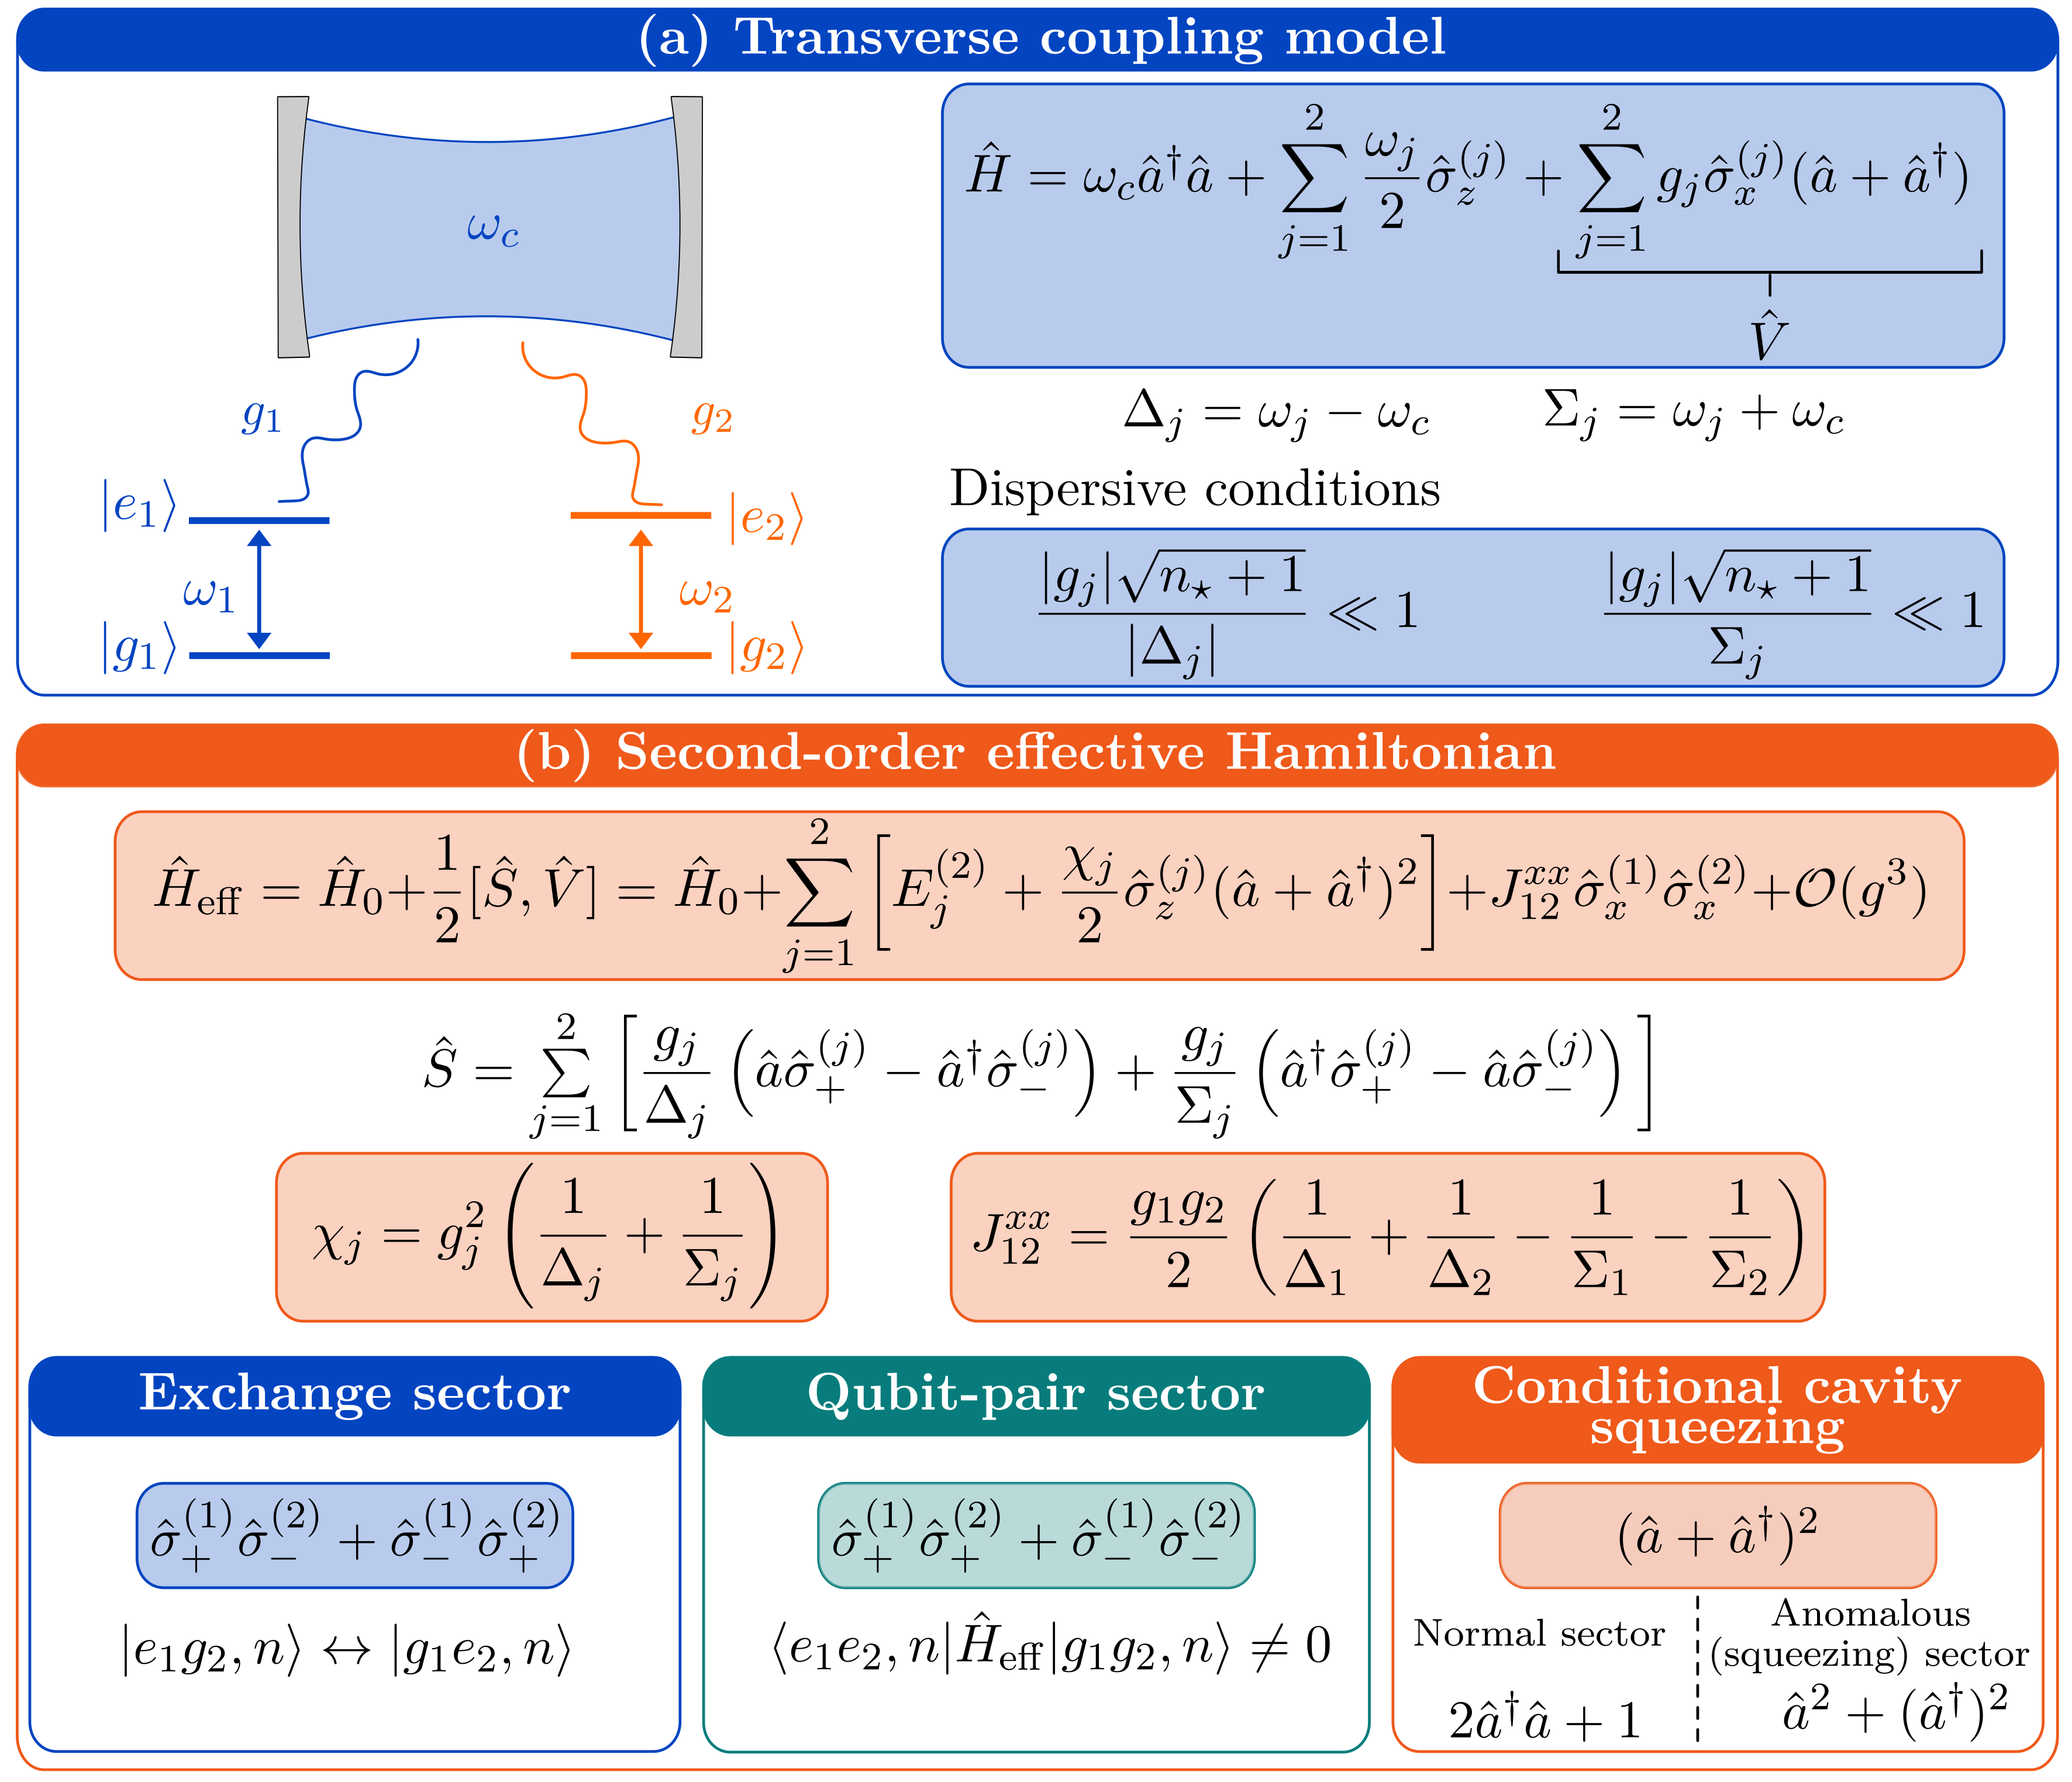

In [34]:
from hashlib import sha256
import shutil
from pathlib import Path
from IPython.display import Image, display

asset_pdf = Path("assets/manuscript/N01_MF1.pdf")
asset_png = Path("assets/manuscript/N01_MF1.png")
target_dir = Path("figures/manuscript")
target_dir.mkdir(parents=True, exist_ok=True)
target_pdf = target_dir / "N01_MF1.pdf"
target_png = target_dir / "N01_MF1.png"
shutil.copy2(asset_pdf, target_pdf)
shutil.copy2(asset_png, target_png)
assert sha256(asset_pdf.read_bytes()).hexdigest() == "e49b990941fbed3d210cb6ef5a822955feeb7c445f9c2d4fc3a321a0adc4064b"
assert sha256(target_pdf.read_bytes()).hexdigest() == "e49b990941fbed3d210cb6ef5a822955feeb7c445f9c2d4fc3a321a0adc4064b"
display(Image(filename=str(target_png), width=920))

In [35]:
# Parameters collected in one place for adaptation and convergence studies.
CORE = {
    "n_cav": 14,
    "omega_c": 1.0,
    "omega_1": 1.5,
    "omega_2": 1.5,
    "g_1": 0.07,
    "g_2": 0.07,
    "n_exchange": 701,
    "n_squeezing": 481,
}

THERMAL = {
    "n_cav": 24,
    "omega_c": 1.0,
    "omega_1": 1.5,
    "g_1": 0.03,
    "g_2": 0.0225,
    "n_time": 361,
    "nbar_grid": np.array([0.0, 0.15, 0.30, 0.45, 0.60, 0.75]),
}

DIAGNOSTICS = {
    "cutoffs": [8, 10, 12, 14, 16, 18],
    "detunings": np.array([0.12, 0.16, 0.20, 0.25, 0.30, 0.40, 0.60, 0.80]),
}

RUN_THERMAL_SCAN = True
RUN_EXPENSIVE_DIAGNOSTICS = True

BASE_SOLVER_OPTIONS = {
    "store_states": True,
    "progress_bar": "",
    "atol": 1e-9,
    "rtol": 1e-9,
    "nsteps": 20000,
}


def solver_options(overrides=None):
    options = dict(BASE_SOLVER_OPTIONS)
    if overrides:
        options.update(overrides)
    return options


In [36]:
def two_qubit_operators(n_cav: int):
    """Operators in the ordering cavity, qubit 1, qubit 2."""
    ic = qeye(n_cav)
    iq = qeye(2)
    a = tensor(destroy(n_cav), iq, iq)
    sp1 = tensor(ic, sigmap(), iq)
    sm1 = tensor(ic, sigmam(), iq)
    sp2 = tensor(ic, iq, sigmap())
    sm2 = tensor(ic, iq, sigmam())
    parity_cavity = Qobj(np.diag((-1.0) ** np.arange(n_cav)))
    return {
        "a": a,
        "n": a.dag() * a,
        "P0_cav": tensor(fock_dm(n_cav, 0), iq, iq),
        "parity": tensor(parity_cavity, sigmaz(), sigmaz()),
        "sx1": tensor(ic, sigmax(), iq),
        "sx2": tensor(ic, iq, sigmax()),
        "sz1": tensor(ic, sigmaz(), iq),
        "sz2": tensor(ic, iq, sigmaz()),
        "sp1": sp1,
        "sp2": sp2,
        "sm1": sm1,
        "sm2": sm2,
        "Pe1": sp1 * sm1,
        "Pe2": sp2 * sm2,
        "pair": sm1 * sm2,
        "I": tensor(ic, iq, iq),
    }


def build_microscopic_model(n_cav, omega_c, omega_1, omega_2, g_1, g_2):
    o = two_qubit_operators(n_cav)
    X = o["a"] + o["a"].dag()
    h0 = omega_c * o["n"] + 0.5 * omega_1 * o["sz1"] + 0.5 * omega_2 * o["sz2"]
    v = g_1 * o["sx1"] * X + g_2 * o["sx2"] * X
    return o, h0, v, h0 + v


## 3. Four interaction-picture harmonics

Using $\sigma\_x=\sigma\_++\sigma\_-$, each qubit contributes four vertices,

$$
V\_I(t)=\sum\_j g\_j\left[
a\sigma\_+^{(j)}e^{+i\Delta\_jt}
+a^\dagger\sigma\_-^{(j)}e^{-i\Delta\_jt}
+a^\dagger\sigma\_+^{(j)}e^{+i\Sigma\_jt}
+a\sigma\_-^{(j)}e^{-i\Sigma\_jt}
\right].
$$

The $\Delta\_j$ vertices exchange one excitation. The $\Sigma\_j$ vertices create or annihilate a qubit and oscillator excitation together. The latter are far off resonance in the dispersive regime, but their virtual commutators generate finite second-order terms.

For harmonic bookkeeping it is useful to write

$$
V\_I(t)=\sum\_r v\_r e^{i\nu\_r t},
$$

where $\nu\_r$ is a **signed** harmonic frequency. For each qubit the list is

$$
\begin{array}{c|c}
v\_r & \nu\_r\\ \hline
g\_j a\sigma\_+^{(j)} & +\Delta\_j\\
g\_j a^\dagger\sigma\_-^{(j)} & -\Delta\_j\\
g\_j a^\dagger\sigma\_+^{(j)} & +\Sigma\_j\\
g\_j a\sigma\_-^{(j)} & -\Sigma\_j
\end{array}
$$

This convention remains valid for positive or negative detuning; no harmonic is called “positive frequency” merely because it was placed in one half of a Hermitian pair.

A useful local control parameter on Fock sectors $n\le n\_\star$ is

$$
\eta\_\star=
\max\_j\left\{
\frac{|g\_j|\sqrt{n\_\star+1}}{|\Delta\_j|},
\frac{|g\_j|\sqrt{n\_\star+1}}{|\Sigma\_j|}
\right\}.
$$


## 4. First operational route: James--Jerke filtering and its completion

The James--Jerke construction is especially operational when the interaction is already decomposed into harmonics [[12]](#ref-james2007). In its common filtered form one pairs Hermitian harmonics,

$$
V\_I(t)=\sum\_\mu\left(
h\_\mu e^{-i\omega\_\mu t}
+h\_\mu^\dagger e^{+i\omega\_\mu t}
\right),
$$

and organizes second-order terms as

$$
H\_{\mathrm{JJ}}^{(2)}(t)
=
\sum\_{\mu,\nu}
\frac{[h\_\mu^\dagger,h\_\nu]}{\bar\omega\_{\mu\nu}}
e^{i(\omega\_\mu-\omega\_\nu)t},
\qquad
\frac{1}{\bar\omega\_{\mu\nu}}
=
\frac12\left(
\frac1{\omega\_\mu}+\frac1{\omega\_\nu}
\right).
$$

This form makes shifts and slowly beating exchange terms easy to identify: list the harmonics, evaluate commutators, and retain the beat frequencies resolved on the timescale of interest. Its compactness is also the source of a common mistake. A slow-frequency filter in the interaction picture can remove terms rotating at $\pm2\omega\_c$ or $\pm(\omega\_1+\omega\_2)$ even though the corresponding operators are static components of the Schrödinger-picture transformed Hamiltonian.

To separate **harmonic bookkeeping** from **temporal filtering**, we first keep all signed components. The first-order interaction-picture generator is

$$
S\_I(t)=\sum\_r\frac{v\_r}{\nu\_r}e^{i\nu\_r t},
$$

and the complete pre-filter second-order operator is

$$
H\_{I,\mathrm{pre}}^{(2)}(t)
=
\frac12[S\_I(t),V\_I(t)]
=
\frac12\sum\_{r,s}
\frac{[v\_r,v\_s]}{\nu\_r}
e^{i(\nu\_r+\nu\_s)t}.
$$

The nonzero commutators fall into four sectors:

* local shifts;
* oscillator-anomalous terms $a^2\sigma\_z^{(j)}$ and $a^{\dagger2}\sigma\_z^{(j)}$;
* qubit exchange $\sigma\_+^{(j)}\sigma\_-^{(k)}$;
* qubit pairs $\sigma\_+^{(j)}\sigma\_+^{(k)}$ and their adjoints.

At $t=0$, this signed-harmonic sum is exactly $\tfrac12[S,V]$. Applying a bandwidth condition **afterward** produces a James--Jerke-type filtered Hamiltonian and reveals precisely which sectors the filter removes.

### What the method makes easy—and what it can hide

James--Jerke filtering is usually the quickest route to an operational dispersive Hamiltonian. It does not, however, display intermediate virtual states as explicitly as projection theory, and it does not automatically provide the encoding and reconstruction maps supplied by SW. We therefore use

$$
\boxed{
\text{James--Jerke: select slow harmonics}
\;\longrightarrow\;
\text{SW: track dressing}
\;\longrightarrow\;
\text{projection: identify virtual paths}
}
$$

as a complementary teaching sequence rather than treating the methods as interchangeable recipes.


In [37]:
def validate_frequency_denominators(omega_c, omegas, tolerance=1e-12):
    denominators = {}
    for index, omega in enumerate(omegas, start=1):
        denominators[f"Delta_{index}"] = omega - omega_c
        denominators[f"Sigma_{index}"] = omega + omega_c
    small = {name: value for name, value in denominators.items() if abs(value) <= tolerance}
    if small:
        details = ", ".join(f"{name}={value:.3e}" for name, value in small.items())
        raise ValueError(
            "A perturbative denominator is zero or numerically singular: " + details
            + ". Enlarge the retained resonant manifold instead of using this elimination."
        )
    return denominators


def signed_harmonics(o, omega_c, omega_1, omega_2, g_1, g_2):
    """Return all signed interaction-picture components v_r exp(i nu_r t)."""
    d = validate_frequency_denominators(omega_c, [omega_1, omega_2])
    parameters = [
        {"label": "1 co +", "qubit": 1, "family": "co", "qop": "raise",
         "operator": g_1 * o["a"] * o["sp1"], "frequency": d["Delta_1"]},
        {"label": "1 co -", "qubit": 1, "family": "co", "qop": "lower",
         "operator": g_1 * o["a"].dag() * o["sm1"], "frequency": -d["Delta_1"]},
        {"label": "1 cr +", "qubit": 1, "family": "cr", "qop": "raise",
         "operator": g_1 * o["a"].dag() * o["sp1"], "frequency": d["Sigma_1"]},
        {"label": "1 cr -", "qubit": 1, "family": "cr", "qop": "lower",
         "operator": g_1 * o["a"] * o["sm1"], "frequency": -d["Sigma_1"]},
        {"label": "2 co +", "qubit": 2, "family": "co", "qop": "raise",
         "operator": g_2 * o["a"] * o["sp2"], "frequency": d["Delta_2"]},
        {"label": "2 co -", "qubit": 2, "family": "co", "qop": "lower",
         "operator": g_2 * o["a"].dag() * o["sm2"], "frequency": -d["Delta_2"]},
        {"label": "2 cr +", "qubit": 2, "family": "cr", "qop": "raise",
         "operator": g_2 * o["a"].dag() * o["sp2"], "frequency": d["Sigma_2"]},
        {"label": "2 cr -", "qubit": 2, "family": "cr", "qop": "lower",
         "operator": g_2 * o["a"] * o["sm2"], "frequency": -d["Sigma_2"]},
    ]
    return parameters


def classify_signed_commutator(component_r, component_s):
    if component_r["qubit"] == component_s["qubit"]:
        return "local shift" if component_r["family"] == component_s["family"] else "oscillator anomalous"
    return "qubit exchange" if component_r["qop"] != component_s["qop"] else "qubit pair"


def signed_harmonic_second_order(harmonics, zero_tolerance=1e-13):
    """Build the complete pre-filter operator 1/2 [S_I(0), V_I(0)]."""
    S_zero = 0 * harmonics[0]["operator"]
    V_zero = 0 * harmonics[0]["operator"]
    rows, operators = [], []
    for component in harmonics:
        S_zero += component["operator"] / component["frequency"]
        V_zero += component["operator"]

    for component_r in harmonics:
        for component_s in harmonics:
            term = 0.5 * commutator(
                component_r["operator"], component_s["operator"]
            ) / component_r["frequency"]
            term_norm = term.norm("fro")
            if term_norm <= zero_tolerance:
                continue
            rows.append({
                "r": component_r["label"],
                "s": component_s["label"],
                "beat_frequency": component_r["frequency"] + component_s["frequency"],
                "sector": classify_signed_commutator(component_r, component_s),
                "term_frobenius_norm": term_norm,
            })
            operators.append(term)

    table = pd.DataFrame(rows)
    complete_operator = 0.5 * commutator(S_zero, V_zero)
    return table, operators, complete_operator, S_zero, V_zero


def filtered_harmonic_operator(table, operators, bandwidth):
    """Retain only interaction-picture beats with |nu_r+nu_s| <= bandwidth."""
    if len(operators) == 0:
        raise ValueError("No nonzero harmonic commutators were generated.")
    result = 0 * operators[0]
    for beat, operator in zip(table["beat_frequency"], operators):
        if abs(beat) <= bandwidth:
            result += operator
    return result

# The complete signed list is evaluated after the benchmark parameters are set.


## 5. Complete SW derivation

The SW transformation provides a systematic block-diagonalization framework and a natural language for dressed states and observables [[13]](#ref-bravyi2011).

We choose

$$
U=e^{-S},\qquad \widetilde H=U^\dagger H U=e^SHe^{-S},
$$

and impose the first-order cancellation condition

$$
[S,H\_0]=-V.
$$

Because each interaction vertex is an eigenoperator of $[H\_0,\cdot]$, the anti-Hermitian generator is

$$
S=\sum\_j\left[
\frac{g\_j}{\Delta\_j}
\left(a\sigma\_+^{(j)}-a^\dagger\sigma\_-^{(j)}\right)
+
\frac{g\_j}{\Sigma\_j}
\left(a^\dagger\sigma\_+^{(j)}-a\sigma\_-^{(j)}\right)
\right].
$$

The Baker--Campbell--Hausdorff series then gives

$$
\widetilde H=H\_0+V+[S,H\_0]+[S,V]+\frac12[S,[S,H\_0]]+\cdots,
$$

so that

$$
H\_{\mathrm{SW}}^{(2)}=H\_0+\frac12[S,V]+\mathcal O(g^3).
$$


In [38]:
def sw_generator(o, omega_c, omega_1, omega_2, g_1, g_2):
    a = o["a"]
    d = validate_frequency_denominators(omega_c, [omega_1, omega_2])
    d1, d2 = d["Delta_1"], d["Delta_2"]
    s1, s2 = d["Sigma_1"], d["Sigma_2"]
    S = (g_1 / d1) * (a * o["sp1"] - a.dag() * o["sm1"])
    S += (g_1 / s1) * (a.dag() * o["sp1"] - a * o["sm1"])
    S += (g_2 / d2) * (a * o["sp2"] - a.dag() * o["sm2"])
    S += (g_2 / s2) * (a.dag() * o["sp2"] - a * o["sm2"])
    return S


def analytic_coefficients(omega_c, omega_1, omega_2, g_1, g_2):
    d = validate_frequency_denominators(omega_c, [omega_1, omega_2])
    d1, d2 = d["Delta_1"], d["Delta_2"]
    s1, s2 = d["Sigma_1"], d["Sigma_2"]
    J_Delta = 0.5 * g_1 * g_2 * (1 / d1 + 1 / d2)
    J_Sigma = -0.5 * g_1 * g_2 * (1 / s1 + 1 / s2)
    return {
        "E_1": 0.5 * g_1**2 * (1 / d1 - 1 / s1),
        "E_2": 0.5 * g_2**2 * (1 / d2 - 1 / s2),
        "chi_1": g_1**2 * (1 / d1 + 1 / s1),
        "chi_2": g_2**2 * (1 / d2 + 1 / s2),
        "J_Delta": J_Delta,
        "J_Sigma": J_Sigma,
        "J_xx": J_Delta + J_Sigma,
        "J_JC": J_Delta,
    }


### 5.1 Same-qubit commutators

The number-conserving contributions follow from

$$
[a\sigma\_+,a^\dagger\sigma\_-]
=\frac12+\left(a^\dagger a+\frac12\right)\sigma\_z,
$$

$$
[a^\dagger\sigma\_+,a\sigma\_-]
=-\frac12+\left(a^\dagger a+\frac12\right)\sigma\_z.
$$

The anomalous oscillator sector follows from the cross-frequency commutators

$$
[a\sigma\_+,a\sigma\_-]=a^2\sigma\_z,
\qquad
[a^\dagger\sigma\_+,a^\dagger\sigma\_-]=a^{\dagger2}\sigma\_z.
$$

These are the terms most easily lost when the derivation silently keeps only products with equal interaction-picture frequencies.


### 5.2 Cross-qubit commutators

Operators acting on different qubits commute, but they share the same oscillator. The complete cross-qubit result is

$$
H\_{12}^{(2)}=J\_{12}^{xx}\sigma\_x^{(1)}\sigma\_x^{(2)},
$$

$$
J\_{12}^{xx}=\frac{g\_1g\_2}{2}
\left(
\frac1{\Delta\_1}+\frac1{\Delta\_2}
-\frac1{\Sigma\_1}-\frac1{\Sigma\_2}
\right).
$$

Since

$$
\sigma\_x^{(1)}\sigma\_x^{(2)}=
\sigma\_+^{(1)}\sigma\_-^{(2)}+
\sigma\_-^{(1)}\sigma\_+^{(2)}+
\sigma\_+^{(1)}\sigma\_+^{(2)}+
\sigma\_-^{(1)}\sigma\_-^{(2)},
$$

the same second-order coefficient contains ordinary exchange and the qubit-pair sector. Whether a particular term becomes resonant depends on the dressed energies or on external modulation; its presence in the static transformed Hamiltonian is not by itself a claim of resonant conversion.


## 6. Complete second-order transformed Hamiltonian

Combining the local and cross-qubit commutators gives

$$
\begin{aligned}
H\_{\mathrm{SW}}^{(2)}={}&H\_0
+\sum\_{j=1}^{2}\left[
E\_j^{(2)}+
\frac{\chi\_j}{2}\sigma\_z^{(j)}(a+a^\dagger)^2
\right]\\
&+J\_{12}^{xx}\sigma\_x^{(1)}\sigma\_x^{(2)}
+\mathcal O(g^3),
\end{aligned}
$$

with

$$
E\_j^{(2)}=\frac{g\_j^2}{2}
\left(\frac1{\Delta\_j}-\frac1{\Sigma\_j}\right),
\qquad
\chi\_j=g\_j^2
\left(\frac1{\Delta\_j}+\frac1{\Sigma\_j}\right).
$$

The phrase **complete second-order transformed Hamiltonian before any additional secular truncation** is more precise than “the unique normal form.” A further near-identity transformation can redistribute off-diagonal second-order terms. Physical equivalence requires consistent transformation of states and observables.

Only the first-order generator $S\_1$ is used here. The displayed operator is therefore correct through second order as a transformed Hamiltonian, but it is not yet a fully block-diagonal second-order normal form: terms such as $a^2$, $a^{\dagger2}$, and $\sigma\_+^{(1)}\sigma\_+^{(2)}$ remain off diagonal with respect to $H\_0$. A second generator $S\_2$ could remove those terms and transfer their effects into higher-order energies and reconstruction maps.


In [39]:
def complete_sw_model(o, h0, v, omega_c, omega_1, omega_2, g_1, g_2):
    S = sw_generator(o, omega_c, omega_1, omega_2, g_1, g_2)
    H_sw = h0 + 0.5 * commutator(S, v)
    U = (-S).expm()
    return H_sw, S, U


def compact_sw_model(o, h0, omega_c, omega_1, omega_2, g_1, g_2):
    c = analytic_coefficients(omega_c, omega_1, omega_2, g_1, g_2)
    X = o["a"] + o["a"].dag()
    H = h0 + (c["E_1"] + c["E_2"]) * o["I"]
    H += 0.5 * c["chi_1"] * o["sz1"] * X**2
    H += 0.5 * c["chi_2"] * o["sz2"] * X**2
    H += c["J_xx"] * o["sx1"] * o["sx2"]
    return H


### 6.1 Direct algebraic verification

A symbolic derivation and a numerical commutator should agree on the retained low-Fock manifold. We test

$$
P\_\star\left[
\frac12[S,V]-
\left(H\_{\mathrm{compact}}^{(2)}-H\_0\right)
\right]P\_\star.
$$

The projection is needed because the finite oscillator cutoff modifies the canonical commutator at the top Fock state. Agreement inside the populated manifold is the relevant statement.


In [40]:
def low_fock_projector(n_cav, n_star):
    P = 0
    for n in range(n_star + 1):
        for q1 in [0, 1]:
            for q2 in [0, 1]:
                P += tensor(
                    ket2dm(fock(n_cav, n)),
                    ket2dm(basis(2, q1)),
                    ket2dm(basis(2, q2)),
                )
    return P


def projected_rms(operator, projector):
    rank = np.real(projector.tr())
    return (projector * operator * projector).norm("fro") / np.sqrt(rank)

# Example verification
n_cav_check = 10
ops_check, h0_check, v_check, _ = build_microscopic_model(
    n_cav_check, 1.0, 1.5, 1.5, 0.07, 0.07
)
h_sw_check, s_check, _ = complete_sw_model(
    ops_check, h0_check, v_check, 1.0, 1.5, 1.5, 0.07, 0.07
)
h_compact_check = compact_sw_model(
    ops_check, h0_check, 1.0, 1.5, 1.5, 0.07, 0.07
)
p_check = low_fock_projector(n_cav_check, 3)

pd.Series({
    "anti-Hermitian generator": (s_check + s_check.dag()).norm(),
    "first-order cancellation": projected_rms(v_check + commutator(s_check, h0_check), p_check),
    "compact Hamiltonian identity": projected_rms(h_sw_check - h_compact_check, p_check),
})


anti-Hermitian generator        0.0
first-order cancellation        0.0
compact Hamiltonian identity    0.0
dtype: float64

## 7. Four models and the two approximation errors they diagnose

The comparison is designed to distinguish two common mistakes that are often conflated.

### 7.1 The two approximation errors

**Error A: apply the microscopic RWA too early.** The vertices $a^\dagger\sigma\_+$ and $a\sigma\_-$ are removed before the effective calculation starts. Their virtual paths, Bloch--Siegert corrections, and anomalous operator sectors can never reappear.

**Error B: derive beyond the RWA, then secularize too aggressively.** The full Rabi interaction is used and its corrected coefficients are derived, but generated pair and squeezing terms are deleted because they rotate rapidly in one chosen interaction picture.

The four models separate these operations:

| Model | What is retained | What it diagnoses |
| --- | --- | --- |
| Microscopic Rabi | All four vertices | Reference dynamics |
| Complete reconstructed SW | All second-order operators plus dressed states and observables | Controlled beyond-RWA prediction |
| Secularized beyond-RWA | Corrected shifts and ordinary exchange, but no dynamical pair or squeezing terms | Error B |
| JC dispersive | Only co-rotating virtual paths | Error A |

The secularized beyond-RWA Hamiltonian is obtained from the complete coefficients by the explicit replacements

$$
(a+a^\dagger)^2\longrightarrow 2a^\dagger a+1,
$$

and

$$
\sigma\_x^{(1)}\sigma\_x^{(2)}
\longrightarrow
\sigma\_+^{(1)}\sigma\_-^{(2)}+
\sigma\_-^{(1)}\sigma\_+^{(2)}.
$$

Thus,

$$
\begin{aligned}
H\_{\mathrm{sec}}^{(2)}={}&H\_0+\sum\_j\left[
E\_j^{(2)}+\chi\_j\left(a^\dagger a+\frac12\right)\sigma\_z^{(j)}
\right]\\
&+J\_{12}^{xx}\left(
\sigma\_+^{(1)}\sigma\_-^{(2)}+
\sigma\_-^{(1)}\sigma\_+^{(2)}
\right).
\end{aligned}
$$

The same full SW encoding and reconstruction are used for the complete and secularized models. Any remaining pair or squeezing signal in the secularized prediction is therefore identifiable as static dressing rather than dynamics generated by the deleted operators.

The secularized model is deliberately constructed to isolate the dynamical effect of deleting the generated pair and squeezing operators while retaining the same first-order full-Rabi dressing. It is a diagnostic comparison, not the unique second-order secular normal form. A systematic normal-form calculation would generally introduce an additional generator $S\_2$ and a correspondingly modified reconstruction map.


In [41]:
def secular_beyond_rwa_model(o, h0, omega_c, omega_1, omega_2, g_1, g_2):
    c = analytic_coefficients(omega_c, omega_1, omega_2, g_1, g_2)
    H = h0 + (c["E_1"] + c["E_2"]) * o["I"]
    H += c["chi_1"] * o["sz1"] * (o["n"] + 0.5 * o["I"])
    H += c["chi_2"] * o["sz2"] * (o["n"] + 0.5 * o["I"])
    H += c["J_xx"] * (o["sp1"] * o["sm2"] + o["sm1"] * o["sp2"])
    return H


def jc_dispersive_model(o, h0, omega_c, omega_1, omega_2, g_1, g_2):
    a = o["a"]
    d = validate_frequency_denominators(omega_c, [omega_1, omega_2])
    d1, d2 = d["Delta_1"], d["Delta_2"]
    v_jc = g_1 * (a * o["sp1"] + a.dag() * o["sm1"])
    v_jc += g_2 * (a * o["sp2"] + a.dag() * o["sm2"])
    s_jc = (g_1 / d1) * (a * o["sp1"] - a.dag() * o["sm1"])
    s_jc += (g_2 / d2) * (a * o["sp2"] - a.dag() * o["sm2"])
    H_jc = h0 + 0.5 * commutator(s_jc, v_jc)
    U_jc = (-s_jc).expm()
    return H_jc, s_jc, U_jc


### 7.2 Six common ways to lose the anomalous sector

1. **Apply the microscopic RWA first.** Counter-rotating vertices are deleted before they can participate in any virtual path.
2. **Use a co-rotating-only generator on the full Rabi Hamiltonian.** The attempted transformation does not cancel the complete interaction, leaving an order-$g$ residual.
3. **Keep only equal-frequency commutator products.** This is convenient in a James--Jerke or Magnus calculation, but it deletes mixed harmonics that generate $a^2+a^{\dagger2}$.
4. **Project onto a fixed total-excitation sector too early.** Pair and squeezing matrix elements vanish because the relevant states were removed before the effective operator was constructed.
5. **Replace $(a+a^\dagger)^2$ by $2a^\dagger a+1$ without naming the second approximation.** This is not algebraic simplification; it is an additional secular truncation with its own timescale and observable dependence.
6. **Validate only populations.** A model may reproduce one transfer probability while giving the wrong pair coherence, quadrature variance, phase, or reduced density matrix.

The numerical hierarchy below is constructed so that each of these losses has a visible signature.


## 8. Encoding, evolution, and reconstruction

The transformed Hamiltonian acts on transformed states,

$$
\widetilde\rho(0)=U^\dagger\rho(0)U,
$$

and the laboratory prediction is reconstructed as

$$
\rho\_{\mathrm{rec}}(t)=
Ue^{-iH\_{\mathrm{eff}}t}
U^\dagger\rho(0)U
e^{+iH\_{\mathrm{eff}}t}U^\dagger.
$$

Equivalently, an observable can be dressed,

$$
\widetilde O=U^\dagger O U.
$$

For the cavity operator,

$$
\widetilde a
=a+
\sum\_j\left(
\frac{g\_j}{\Delta\_j}\sigma\_-^{(j)}
-
\frac{g\_j}{\Sigma\_j}\sigma\_+^{(j)}
\right)+\mathcal O(g^2).
$$

The calculation below uses the full exponential $U=e^{-S}$ as a unitary reconstruction. This is a convenient partial resummation; it should be distinguished from a strictly order-by-order truncation of the reconstruction map.

In open systems, the same representation change must also be applied to the environmental coupling and jump operators; bare dissipators can become inconsistent in ultrastrong or strongly dressed regimes [[17]](#ref-beaudoin2011).


In [42]:
def encoded_state(physical_state, U):
    return U.dag() * physical_state


def reconstructed_states(effective_states, U):
    return [U * state for state in effective_states]


def density_operator(state):
    return ket2dm(state) if state.isket else state


def reduced_qubits(state):
    return density_operator(state).ptrace([1, 2])


def minimum_quadrature_variance(state, a):
    mean_a = expect(a, state)
    mean_n = expect(a.dag() * a, state)
    centered_a2 = expect(a * a, state) - mean_a**2
    return float(np.real(mean_n + 0.5 - abs(mean_a)**2 - abs(centered_a2)))


def observable_table(states, o):
    return pd.DataFrame({
        "P_e2": [expect(o["Pe2"], s) for s in states],
        "concurrence": [concurrence(reduced_qubits(s)) for s in states],
        "Vmin": [minimum_quadrature_variance(s, o["a"]) for s in states],
        "Re_a2": [np.real(expect(o["a"] * o["a"], s)) for s in states],
        "Abs_pair": [abs(expect(o["pair"], s)) for s in states],
        "n_cavity": [expect(o["n"], s) for s in states],
        "P_cavity_excited": [
            1.0 - np.real(expect(o["P0_cav"], s)) for s in states
        ],
    })


In [43]:
def evolve_pure_hierarchy(
    psi0, tlist, h_full, h_sw, U_sw, h_sec, h_jc, U_jc, options=None
):
    opts = solver_options(options)
    full = sesolve(h_full, psi0, tlist, e_ops=None, options=opts).states
    sw_tilde = sesolve(
        h_sw, encoded_state(psi0, U_sw), tlist, e_ops=None, options=opts
    ).states
    sec_tilde = sesolve(
        h_sec, encoded_state(psi0, U_sw), tlist, e_ops=None, options=opts
    ).states
    jc_tilde = sesolve(
        h_jc, encoded_state(psi0, U_jc), tlist, e_ops=None, options=opts
    ).states
    return {
        "full Rabi": full,
        "complete SW": reconstructed_states(sw_tilde, U_sw),
        "secular SW": reconstructed_states(sec_tilde, U_sw),
        "JC dispersive": reconstructed_states(jc_tilde, U_jc),
    }


## 9. Central exact-versus-effective comparison

The upper panels start from $|eg,0\rangle$ and test qubit transfer and entanglement. The lower panels start from the bare factorized state $|gg,0\rangle$ and test quench-induced dynamical squeezing. The latter is not automatically ground-state squeezing, stationary output squeezing, or a metrological resource.

The parameter set is

$$
\omega\_c=1,
\quad
\omega\_1=\omega\_2=1.5,
\quad
g\_1=g\_2=0.07,
\quad
N\_{\mathrm{cav}}=14.
$$

For these values, $J\_{12}^{xx}=7.84\times10^{-3}$ and the JC exchange coefficient is larger, $J\_{12}^{\mathrm{JC}}=9.80\times10^{-3}$. This coefficient difference produces a visible phase error even when the JC population curve initially looks plausible.


### 9.1 Claim--diagnostic map

Each physical claim is paired with an observable that tests the claimed operator sector and with a diagnostic that tests the approximation used to expose it.

| Claimed physics | Initial state | Primary observable | Validity diagnostic |
| --- | --- | --- | --- |
| Qubit exchange | $|eg,0\rangle$ | $P_{e,2}$ and concurrence | $P_{\mathrm{cav}>0}$ and reduced-state trace distance |
| Qubit-pair sector | $|gg,0\rangle$ | $|\langle\sigma_-^{(1)}\sigma_-^{(2)}\rangle|$ | parity conservation and reconstruction-order sensitivity |
| Conditional oscillator squeezing | $|gg,0\rangle$ | $V_{\min}$ and $\langle a^2\rangle$ | Fock-cutoff convergence and reconstruction order |
| Elimination breakdown | detuning scan | reduced-state trace distance | cavity-manifold leakage and mean cavity occupation |

The direct leakage probability is

$$
P_{\mathrm{cav}>0}(t)=1-\left\langle |0\rangle\langle0|\otimes I_{12}\right\rangle.
$$

Unlike $\langle a^\dagger a\rangle$, it measures the total probability of leaving the eliminated cavity-vacuum manifold, irrespective of how that probability is distributed over excited Fock states.


In [44]:
n_cav = CORE["n_cav"]
omega_c = CORE["omega_c"]
omega_1 = CORE["omega_1"]
omega_2 = CORE["omega_2"]
g_1 = CORE["g_1"]
g_2 = CORE["g_2"]

ops, h0, v, h_full = build_microscopic_model(
    n_cav, omega_c, omega_1, omega_2, g_1, g_2
)
h_sw, s_sw, U_sw = complete_sw_model(
    ops, h0, v, omega_c, omega_1, omega_2, g_1, g_2
)
h_sec = secular_beyond_rwa_model(
    ops, h0, omega_c, omega_1, omega_2, g_1, g_2
)
h_jc, s_jc, U_jc = jc_dispersive_model(
    ops, h0, omega_c, omega_1, omega_2, g_1, g_2
)
coeff = analytic_coefficients(omega_c, omega_1, omega_2, g_1, g_2)
pd.Series(coeff)


E_1        0.00392
E_2        0.00392
chi_1      0.01176
chi_2      0.01176
J_Delta    0.00980
J_Sigma   -0.00196
J_xx       0.00784
J_JC       0.00980
dtype: float64

### 9.2 Numerical decomposition of the mediated interaction

The ordinary and counter-rotating virtual paths contribute separately,

$$
J_{\Delta}=\frac{g_1g_2}{2}\left(\frac{1}{\Delta_1}+\frac{1}{\Delta_2}\right),
\qquad
J_{\Sigma}=-\frac{g_1g_2}{2}\left(\frac{1}{\Sigma_1}+\frac{1}{\Sigma_2}\right),
$$

so that

$$
J_{12}^{xx}=J_{\Delta}+J_{\Sigma}.
$$

The table below makes the counter-rotating correction visible for the benchmark rather than leaving it implicit in the final coefficient.

In [45]:
virtual_path_coefficients = pd.DataFrame([
    {
        "contribution": "co-rotating paths J_Delta",
        "coefficient": coeff["J_Delta"],
        "fraction_of_J_Delta": 1.0,
    },
    {
        "contribution": "counter-rotating paths J_Sigma",
        "coefficient": coeff["J_Sigma"],
        "fraction_of_J_Delta": coeff["J_Sigma"] / coeff["J_Delta"],
    },
    {
        "contribution": "complete J_xx",
        "coefficient": coeff["J_xx"],
        "fraction_of_J_Delta": coeff["J_xx"] / coeff["J_Delta"],
    },
])
virtual_path_display = (
    virtual_path_coefficients
    .assign(path=["J_Delta", "J_Sigma", "J_xx"])
    .set_index("path")[["coefficient", "fraction_of_J_Delta"]]
    .rename(columns={"coefficient": "value", "fraction_of_J_Delta": "relative"})
)
display(virtual_path_display)

,value,relative
path,,
J_Delta,0.00980,1.0
J_Sigma,-0.00196,-0.2
J_xx,0.00784,0.8


In [46]:
# Apply the complete signed-harmonic bookkeeping to the benchmark.
harmonics = signed_harmonics(ops, omega_c, omega_1, omega_2, g_1, g_2)
(
    harmonic_term_table,
    harmonic_term_operators,
    harmonic_second_order,
    harmonic_generator_zero,
    harmonic_interaction_zero,
) = signed_harmonic_second_order(harmonics)

p_harmonic = low_fock_projector(n_cav, 3)
harmonic_verification = pd.Series({
    "S_I(0) versus static S": projected_rms(harmonic_generator_zero - s_sw, p_harmonic),
    "V_I(0) versus static V": projected_rms(harmonic_interaction_zero - v, p_harmonic),
    "full signed harmonics versus 1/2[S,V]": projected_rms(
        harmonic_second_order - 0.5 * commutator(s_sw, v), p_harmonic
    ),
})

sector_summary = (
    harmonic_term_table
    .groupby("sector", as_index=False)
    .agg(
        nonzero_ordered_terms=("sector", "size"),
        minimum_abs_beat=("beat_frequency", lambda x: np.min(np.abs(x))),
        maximum_abs_beat=("beat_frequency", lambda x: np.max(np.abs(x))),
    )
)

# A zero-beat interaction-picture filter keeps the slow shifts and exchange
# but removes pair and oscillator-anomalous sectors in this symmetric example.
zero_beat_operator = filtered_harmonic_operator(
    harmonic_term_table, harmonic_term_operators, bandwidth=1e-10
)

filter_summary = (
    harmonic_term_table
    .assign(retained_zero_beat=lambda frame: np.abs(frame["beat_frequency"]) <= 1e-10)
    .groupby(["sector", "retained_zero_beat"], as_index=False)
    .size()
)

display(sector_summary)
display(filter_summary)
display(harmonic_verification)


,sector,nonzero_ordered_terms,minimum_abs_beat,maximum_abs_beat
0,local shift,8,0.0,0.0
1,oscillator anomalous,8,2.0,2.0
2,qubit exchange,8,0.0,0.0
3,qubit pair,8,3.0,3.0


,sector,retained_zero_beat,size
0,local shift,True,8
1,oscillator anomalous,False,8
2,qubit exchange,True,8
3,qubit pair,False,8


S_I(0) versus static S                   0.0
V_I(0) versus static V                   0.0
full signed harmonics versus 1/2[S,V]    0.0
dtype: float64

In [47]:
ket_e, ket_g = basis(2, 0), basis(2, 1)
psi_exchange = tensor(fock(n_cav, 0), ket_e, ket_g)
psi_squeezing = tensor(fock(n_cav, 0), ket_g, ket_g)

t_exchange = np.linspace(
    0, 1.10 * np.pi / (2 * abs(coeff["J_xx"])), CORE["n_exchange"]
)
t_squeezing = np.linspace(0, 60, CORE["n_squeezing"])

states_exchange = evolve_pure_hierarchy(
    psi_exchange, t_exchange, h_full, h_sw, U_sw, h_sec, h_jc, U_jc
)
states_squeezing = evolve_pure_hierarchy(
    psi_squeezing, t_squeezing, h_full, h_sw, U_sw, h_sec, h_jc, U_jc
)

exchange_data = {
    name: observable_table(states, ops)
    for name, states in states_exchange.items()
}
squeezing_data = {
    name: observable_table(states, ops)
    for name, states in states_squeezing.items()
}


### 9.3 $\mathbb Z_2$ parity audit

The full transverse model does not conserve the ordinary excitation number. Its exact discrete symmetry is instead

$$
\Pi=(-1)^{a^\dagger a}\sigma_z^{(1)}\sigma_z^{(2)}.
$$

Exchange, qubit-pair, and oscillator-squeezing operators all preserve this parity. Therefore, removing anomalous sectors is not required by symmetry; it is an additional secular approximation. The audit tests both Hamiltonian commutators and the maximum parity drift along the two representative trajectories.

In [48]:
def relative_commutator_norm(H, symmetry):
    denominator = max(H.norm("fro"), np.finfo(float).tiny)
    return commutator(H, symmetry).norm("fro") / denominator


def maximum_symmetry_drift(states, symmetry):
    values = np.real(np.asarray([expect(symmetry, state) for state in states]))
    return float(np.max(np.abs(values - values[0])))


hamiltonian_models = {
    "full Rabi": h_full,
    "complete SW": h_sw,
    "secular SW": h_sec,
    "JC dispersive": h_jc,
}
parity_audit = pd.DataFrame([
    {
        "model": name,
        "relative_commutator_norm": relative_commutator_norm(H, ops["parity"]),
        "exchange_parity_drift": maximum_symmetry_drift(
            states_exchange[name], ops["parity"]
        ),
        "squeezing_parity_drift": maximum_symmetry_drift(
            states_squeezing[name], ops["parity"]
        ),
    }
    for name, H in hamiltonian_models.items()
])
parity_audit_display = (
    parity_audit
    .set_index("model")
    .rename(columns={
        "relative_commutator_norm": "commutator",
        "exchange_parity_drift": "drift_exchange",
        "squeezing_parity_drift": "drift_squeezing",
    })
)
display(parity_audit_display)

,commutator,drift_exchange,drift_squeezing
model,,,
full Rabi,0.0,8.881784e-16,7.771561e-16
complete SW,0.0,1.332268e-15,1.110223e-15
secular SW,0.0,1.554312e-15,9.992007e-16
JC dispersive,0.0,8.881784e-16,4.440892e-16


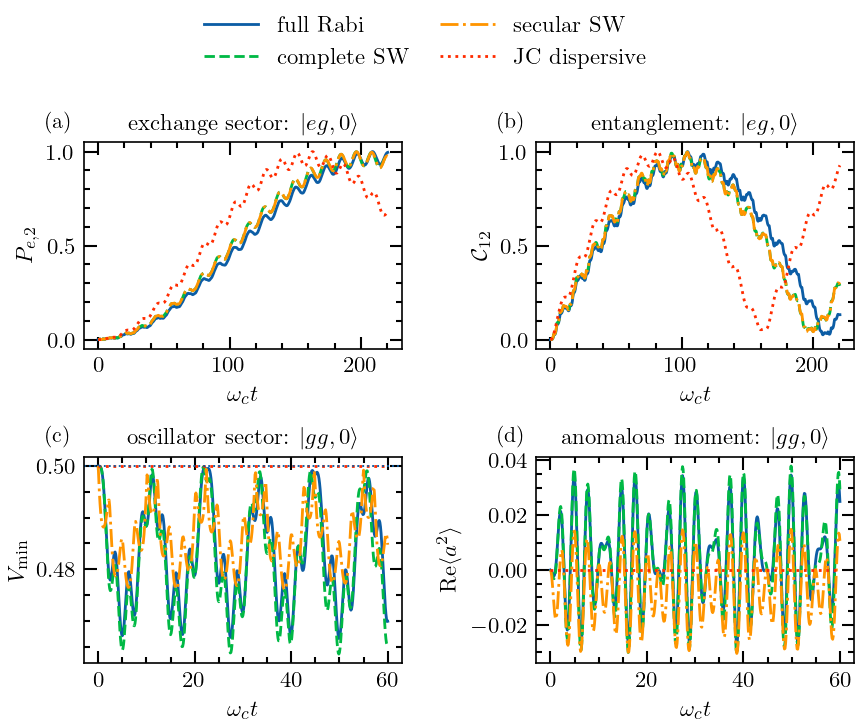

In [49]:
styles = {
    "full Rabi": "-",
    "complete SW": "--",
    "secular SW": "-.",
    "JC dispersive": ":",
}

fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH_150MM, 5.0))
for name, linestyle in styles.items():
    axes[0, 0].plot(t_exchange, exchange_data[name]["P_e2"], ls=linestyle, label=name)
    axes[0, 1].plot(t_exchange, exchange_data[name]["concurrence"], ls=linestyle)
    axes[1, 0].plot(t_squeezing, squeezing_data[name]["Vmin"], ls=linestyle)
    axes[1, 1].plot(t_squeezing, squeezing_data[name]["Re_a2"], ls=linestyle)

axes[0, 0].set(xlabel=r"$\omega_c t$", ylabel=r"$P_{e,2}$", title=r"exchange sector: $|eg,0\rangle$")
axes[0, 1].set(xlabel=r"$\omega_c t$", ylabel=r"$\mathcal{C}_{12}$", title=r"entanglement: $|eg,0\rangle$")
axes[1, 0].set(xlabel=r"$\omega_c t$", ylabel=r"$V_{\min}$", title=r"oscillator sector: $|gg,0\rangle$")
axes[1, 1].set(xlabel=r"$\omega_c t$", ylabel=r"$\mathrm{Re}\langle a^2\rangle$", title=r"anomalous moment: $|gg,0\rangle$")
axes[1, 0].axhline(0.5, ls=":", lw=0.9)
for label, ax in zip(["(a)", "(b)", "(c)", "(d)"], axes.flat):
    ax.text(
        -0.12, 1.04, label, transform=ax.transAxes,
        fontsize=10.5, fontweight="bold", va="bottom", ha="left"
    )
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="upper center", ncol=2,
    bbox_to_anchor=(0.5, 0.995), handlelength=2.4, columnspacing=1.4
)
fig.subplots_adjust(
    left=0.115, right=0.985, bottom=0.105, top=0.80,
    wspace=0.42, hspace=0.52
)
fig.savefig(
    FIGURE_MANUSCRIPT / "N01_MF2_modified.pdf"
)
fig.savefig(
    FIGURE_MANUSCRIPT / "N01_MF2_modified.png",
    dpi=600
)
plt.show()
plt.close(fig)


**What the figure establishes.** The complete SW model tracks the microscopic exchange and entanglement far better than the JC coefficient. More importantly, the JC model predicts $V\_{\min}=1/2$ and $\langle a^2\rangle=0$ because the anomalous sector does not exist in that model. The secularized beyond-RWA model is more subtle: full SW reconstruction leaves virtual dressing, but the removed $a^2+a^{\dagger2}$ term no longer generates the complete dynamical response.

## 10. A pair-sensitive observable and a state-sensitive error

The pair moment

$$
\left|\langle\sigma\_-^{(1)}\sigma\_-^{(2)}\rangle\right|
$$

directly tests a sector that is identically absent in the JC dispersive model. It should not be used alone to distinguish the complete and secularized beyond-RWA models, because reconstruction itself generates virtual pair coherence. Concurrence is evaluated using the two-qubit construction of Wootters [[21]](#ref-wootters1998). The reduced two-qubit trace distance is more discriminating:

$$
D(\rho,\sigma)=\frac12\|\rho-\sigma\|\_1.
$$


In [50]:
full_reduced = [rho.ptrace([1, 2]) for rho in states_exchange["full Rabi"]]
trace_distance = {}
for name in ["complete SW", "secular SW", "JC dispersive"]:
    reduced = [rho.ptrace([1, 2]) for rho in states_exchange[name]]
    trace_distance[name] = np.array([
        tracedist(rho_full, rho_eff) for rho_full, rho_eff in zip(full_reduced, reduced)
    ])

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 3.05))
for name, linestyle in styles.items():
    axes[0].plot(t_squeezing, squeezing_data[name]["Abs_pair"], ls=linestyle, label=name)
for name in ["complete SW", "secular SW", "JC dispersive"]:
    axes[1].plot(t_exchange, trace_distance[name], ls=styles[name], label=name)
axes[0].set(xlabel=r"$\omega_c t$", ylabel=r"$|\langle\sigma_-^{(1)}\sigma_-^{(2)}\rangle|$", title=r"pair-sensitive observable: $|gg,0\rangle$")
axes[1].set(xlabel=r"$\omega_c t$", ylabel=r"$D(\rho_{12}^{\rm full},\rho_{12}^{\rm eff})$", title=r"reduced-state error: $|eg,0\rangle$")
for label, ax in zip(["(a)", "(b)"], axes):
    ax.text(
        -0.12, 1.04, label, transform=ax.transAxes,
        fontsize=10.5, fontweight="bold", va="bottom", ha="left"
    )
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="upper center", ncol=2,
    bbox_to_anchor=(0.5, 0.995), handlelength=2.4, columnspacing=1.3
)
fig.subplots_adjust(
    left=0.12, right=0.985, bottom=0.18, top=0.72, wspace=0.42
)
fig.savefig(
    FIGURE_DIR / "N01_F1.pdf"
)
fig.savefig(
    FIGURE_DIR / "N01_F1.png",
    dpi=600
)
plt.close(fig)


A useful lesson appears here: two models can predict similar transfer populations while differing strongly at the reduced-state level. Validation must be matched to the intended claim.

Panel (b) contains only effective-model errors because the full Rabi trajectory is the reference state, not an additional error curve.

### 10.1 Does the full exponential reconstruction change the conclusion?

Using $U=e^{-S\_1}$ together with a Hamiltonian truncated at second order is a unitary partial resummation. To test whether the plotted conclusions depend on that choice, we compare it with first- and second-order truncated maps,

$$
\mathcal E^{(1)}=I+S\_1,
\qquad
\mathcal R^{(1)}=I-S\_1,
$$

and

$$
\mathcal E^{(2)}=I+S\_1+\frac12S\_1^2,
\qquad
\mathcal R^{(2)}=I-S\_1+\frac12S\_1^2.
$$

Because truncated maps are not exactly unitary, the approximate kets are normalized before observables are evaluated. The table reports the maximum difference from the full-exponential reconstructed SW prediction over the same time windows used in Figs. 1 and 2.


In [51]:
def truncated_sw_map(S, sign, order):
    if order not in (1, 2):
        raise ValueError("order must be 1 or 2")
    identity = qeye(S.dims[0])
    result = identity + sign * S
    if order == 2:
        result += 0.5 * S * S
    return result


def reconstruction_order_states(psi0, tlist, h_sw, S, order):
    encoder = truncated_sw_map(S, +1, order)
    reconstructor = truncated_sw_map(S, -1, order)
    encoded = (encoder * psi0).unit()
    effective = sesolve(
        h_sw, encoded, tlist, e_ops=None, options=solver_options()
    ).states
    return [(reconstructor * state).unit() for state in effective]


reconstruction_rows = []
for order in (1, 2):
    exchange_order = reconstruction_order_states(
        psi_exchange, t_exchange, h_sw, s_sw, order
    )
    squeezing_order = reconstruction_order_states(
        psi_squeezing, t_squeezing, h_sw, s_sw, order
    )
    p_reference = exchange_data["complete SW"]["P_e2"].to_numpy()
    p_order = np.array([expect(ops["Pe2"], state) for state in exchange_order])
    v_reference = squeezing_data["complete SW"]["Vmin"].to_numpy()
    v_order = np.array([
        minimum_quadrature_variance(state, ops["a"])
        for state in squeezing_order
    ])
    d_order = np.array([
        tracedist(reduced_qubits(reference), reduced_qubits(approximate))
        for reference, approximate in zip(
            states_exchange["complete SW"], exchange_order
        )
    ])
    reconstruction_rows.append({
        "truncation_order": order,
        "max_abs_P_e2": np.max(np.abs(p_order - p_reference)),
        "max_abs_Vmin": np.max(np.abs(v_order - v_reference)),
        "max_reduced_trace_distance": d_order.max(),
    })

reconstruction_order_summary = pd.DataFrame(reconstruction_rows)
reconstruction_order_summary


,truncation_order,max_abs_P_e2,max_abs_Vmin,max_reduced_trace_distance
0,1,0.001134,0.015422,0.020829
1,2,0.001166,0.000901,0.001548


## Core conclusion

The calculation has separated three distinct approximation steps:

* removing counter-rotating vertices from the microscopic Hamiltonian;
* deriving the full second-order transformed Hamiltonian;
* secularizing that transformed Hamiltonian again.

These steps do not lose the same physics. The JC model changes coefficients and deletes anomalous sectors. The secularized beyond-RWA model keeps improved shifts and exchange, but removes anomalous evolution. Encoding and reconstruction recover virtual dressing, not the missing generator dynamics.

A first lecture or self-study session may stop here.


# Advanced research path

## 11. Projection and resolvent: the virtual paths behind exchange

Projection and resolvent methods organize the influence of eliminated sectors through energy-dependent virtual propagation [[20]](#ref-feshbach1958).

For the zero-photon exchange $|eg,0\rangle\leftrightarrow|ge,0\rangle$, two representative intermediate states are

$$
|eg,0\rangle\rightarrow|gg,1\rangle\rightarrow|ge,0\rangle,
$$

and

$$
|eg,0\rangle\rightarrow|ee,1\rangle\rightarrow|ge,0\rangle.
$$

The first path carries a difference-frequency denominator, while the second is enabled by a counter-rotating vertex and carries a sum-frequency denominator. Degenerate perturbation theory symmetrizes denominators associated with the initial and final states. The resulting coherent path sum reproduces $J\_{12}^{xx}$.

This viewpoint answers “which virtual states carry the interaction?” SW answers the complementary question “which dressed representation removes the coupling and how must states and observables be transformed?”


## 12. What James--Jerke, SW, and projection each reveal

The three constructions reorganize the same perturbative physics but answer different questions.

| Method | Easiest question to answer | Information it can hide |
| --- | --- | --- |
| James--Jerke | Which second-order operators follow from the oscillating harmonics? | Intermediate virtual states, dressed states, and the consequences of a chosen frequency filter |
| Schrieffer--Wolff | Which transformation decouples the sectors, and how are states and observables dressed? | The individual path interpretation can be less visually immediate |
| Projection/resolvent | Which intermediate states and denominators carry a selected transition? | A compact global reconstruction map is not automatic |

The mixed-harmonic phase

$$
e^{i\Delta\_jt}e^{-i\Sigma\_jt}=e^{-2i\omega\_ct}
$$

is the instructive example. A coarse-graining rule that keeps only zero beat frequency removes this contribution. In a static SW representation, however, the same algebra appears as the operator $a^2+a^{\dagger2}$. The apparent disagreement is resolved only after the frame, temporal bandwidth, retained observable, and reconstruction convention are specified.

A useful working strategy is therefore

$$
\text{James--Jerke for rapid construction}
\;\longrightarrow\;
\text{SW for reconstruction}
\;\longrightarrow\;
\text{projection for path interpretation}.
$$


## 13. Cavity preparation changes mediated qubit dynamics

The number-conserving part contains

$$
H\_{\mathrm{disp}}\supset
\sum\_j\chi\_j\left(a^\dagger a+\frac12\right)\sigma\_z^{(j)}.
$$

In Fock sector $n$,

$$
\widetilde\omega\_j(n)=\omega\_j+\chi\_j(2n+1),
$$

so the relative qubit detuning becomes

$$
\delta\_{12}(n)=\delta\_{12}(0)+2n(\chi\_1-\chi\_2).
$$

A thermal cavity therefore averages qubit trajectories with different phases. The damping-like collapse is closed-system inhomogeneous phase averaging, not irreversible Markovian dephasing. Concurrence must be computed from the thermally averaged density matrix; it cannot be averaged sector by sector because it is nonlinear.


In [52]:
def thermal_weights(nbar, cutoff):
    """Normalized truncated thermal weights p_n for n=0,...,cutoff-1."""
    weights = np.zeros(cutoff, dtype=float)
    if nbar == 0:
        weights[0] = 1.0
        return weights
    q = nbar / (1.0 + nbar)
    weights = (1.0 - q) * q ** np.arange(cutoff)
    return weights / weights.sum()


def fock_component_initial_matrix(n_cav, q1, q2):
    """Columns are |n,q1,q2> for all cavity Fock sectors."""
    columns = [
        tensor(fock(n_cav, n), q1, q2).full().ravel()
        for n in range(n_cav)
    ]
    return np.column_stack(columns)


def diagonalized_component_cache(H, initial_matrix, tlist, n_cav, encode=None, reconstruct=None):
    """Propagate every pure initial Fock component after one diagonalization.

    Returns reduced two-qubit density matrices and the population of the
    highest retained cavity level.  This is exact for the truncated,
    closed, time-independent Hamiltonian.
    """
    H_dense = H.full()
    dimension = H_dense.shape[0]
    identity = np.eye(dimension, dtype=complex)
    encode_matrix = identity if encode is None else encode.full()
    reconstruct_matrix = identity if reconstruct is None else reconstruct.full()

    eigenvalues, eigenvectors = np.linalg.eigh(H_dense)
    coefficients = eigenvectors.conj().T @ (encode_matrix @ initial_matrix)
    physical_eigenvectors = reconstruct_matrix @ eigenvectors

    n_component = initial_matrix.shape[1]
    reduced = np.empty((len(tlist), n_component, 4, 4), dtype=complex)
    top_population = np.empty((len(tlist), n_component), dtype=float)

    for time_index, time in enumerate(tlist):
        phases = np.exp(-1j * eigenvalues * time)[:, None]
        states = physical_eigenvectors @ (phases * coefficients)
        amplitudes = states.reshape(n_cav, 4, n_component)
        reduced[time_index] = np.einsum(
            "aqn,arn->nqr", amplitudes, amplitudes.conj(), optimize=True
        )
        top_population[time_index] = np.sum(
            np.abs(amplitudes[-1]) ** 2, axis=0
        )

    return {"rho_qubits": reduced, "top_population": top_population}


def thermal_reduced_trajectory(component_cache, weights):
    """Form rho_12(t)=sum_n p_n rho_12^(n)(t)."""
    return np.tensordot(component_cache["rho_qubits"], weights, axes=([1], [0]))


def reduced_observable_data(reduced_trajectory):
    projector_q2_excited = np.diag([1.0, 0.0, 1.0, 0.0])
    p_e2 = np.real(np.einsum(
        "tij,ji->t", reduced_trajectory, projector_q2_excited, optimize=True
    ))
    concurrence_values = np.array([
        concurrence(qutip.Qobj(rho, dims=[[2, 2], [2, 2]]))
        for rho in reduced_trajectory
    ])
    return pd.DataFrame({"P_e2": p_e2, "concurrence": concurrence_values})


def reduced_trace_distance(a, b):
    return np.array([
        tracedist(
            qutip.Qobj(rho_a, dims=[[2, 2], [2, 2]]),
            qutip.Qobj(rho_b, dims=[[2, 2], [2, 2]]),
        )
        for rho_a, rho_b in zip(a, b)
    ])


### 13.1 Controlled asymmetric benchmark and Fock-resolved thermal propagation

The thermal benchmark uses weaker couplings and a larger cutoff,

$$
N\_{\mathrm{cav}}=24,
\qquad
g\_1=0.03,
\qquad
g\_2=0.0225,
$$

with $\omega\_2$ chosen so that the vacuum-sector dressed qubit frequencies agree. The scan extends to $\bar n=0.75$.

The initial thermal state is diagonal in the cavity Fock basis,

$$
\rho\_{\mathrm{th}}
=
\sum\_n p\_n|n\rangle\langle n|.
$$

Linearity therefore permits the reduced trajectory to be assembled from pure-state evolutions initialized at $|n,e,g\rangle$,

$$
\rho\_{12}^{(\bar n)}(t)
=
\sum\_n p\_n(\bar n)\rho\_{12}^{(n)}(t).
$$

Each Hamiltonian is diagonalized once, and all initial Fock components are propagated in one batch. These components are not invariant Fock sectors of the full Rabi Hamiltonian: the subsequent dynamics can populate other photon numbers while preserving only the exact parity symmetry. Concurrence is evaluated after the weighted reduced density matrix has been assembled, because concurrence is nonlinear.

The batched construction is checked below against direct QuTiP propagation of the mixed thermal density operator.


In [53]:
def chi_value(omega_q, g, omega_c):
    return g**2 * (1 / (omega_q - omega_c) + 1 / (omega_q + omega_c))

n_cav_th = THERMAL["n_cav"]
omega_c_th = THERMAL["omega_c"]
omega_1_th = THERMAL["omega_1"]
g_1_th = THERMAL["g_1"]
g_2_th = THERMAL["g_2"]
chi_1_th = chi_value(omega_1_th, g_1_th, omega_c_th)
omega_2_th = brentq(
    lambda w: w + chi_value(w, g_2_th, omega_c_th)
    - (omega_1_th + chi_1_th),
    1.2, 1.8,
)

ops_th, h0_th, v_th, h_full_th = build_microscopic_model(
    n_cav_th, omega_c_th, omega_1_th, omega_2_th, g_1_th, g_2_th
)
h_sw_th, s_sw_th, U_sw_th = complete_sw_model(
    ops_th, h0_th, v_th, omega_c_th, omega_1_th, omega_2_th, g_1_th, g_2_th
)
h_jc_th, s_jc_th, U_jc_th = jc_dispersive_model(
    ops_th, h0_th, omega_c_th, omega_1_th, omega_2_th, g_1_th, g_2_th
)
coeff_th = analytic_coefficients(
    omega_c_th, omega_1_th, omega_2_th, g_1_th, g_2_th
)
t_thermal = np.linspace(
    0,
    1.08 * np.pi / (2 * abs(coeff_th["J_xx"])),
    THERMAL["n_time"],
)


In [54]:
if not RUN_THERMAL_SCAN:
    raise RuntimeError("Set RUN_THERMAL_SCAN=True to execute the thermal path.")

def thermal_tail(nbar, cutoff):
    if nbar == 0:
        return 0.0
    q = nbar / (1.0 + nbar)
    return q ** cutoff


def thermal_n_star(nbar, tolerance=1e-6):
    if nbar == 0:
        return 0
    q = nbar / (1.0 + nbar)
    return int(np.ceil(np.log(tolerance) / np.log(q))) - 1


def local_control_parameter(omega_c, omegas, couplings, n_star):
    values = []
    for omega, g in zip(omegas, couplings):
        values.extend([
            abs(g) * np.sqrt(n_star + 1) / abs(omega - omega_c),
            abs(g) * np.sqrt(n_star + 1) / abs(omega + omega_c),
        ])
    return max(values)

# One batch of pure initial Fock components is reused for every temperature.
initial_component_matrix = fock_component_initial_matrix(n_cav_th, ket_e, ket_g)
component_cache = {
    "full Rabi": diagonalized_component_cache(
        h_full_th, initial_component_matrix, t_thermal, n_cav_th
    ),
    "complete SW": diagonalized_component_cache(
        h_sw_th,
        initial_component_matrix,
        t_thermal,
        n_cav_th,
        encode=U_sw_th.dag(),
        reconstruct=U_sw_th,
    ),
    "JC dispersive": diagonalized_component_cache(
        h_jc_th,
        initial_component_matrix,
        t_thermal,
        n_cav_th,
        encode=U_jc_th.dag(),
        reconstruct=U_jc_th,
    ),
}

nbar_grid = THERMAL["nbar_grid"]
thermal_runs = {}
summary_rows = []

for nbar in nbar_grid:
    weights = thermal_weights(nbar, n_cav_th)
    reduced_states = {
        name: thermal_reduced_trajectory(cache, weights)
        for name, cache in component_cache.items()
    }
    data = {
        name: reduced_observable_data(trajectory)
        for name, trajectory in reduced_states.items()
    }
    distances_sw = reduced_trace_distance(
        reduced_states["full Rabi"], reduced_states["complete SW"]
    )
    distances_jc = reduced_trace_distance(
        reduced_states["full Rabi"], reduced_states["JC dispersive"]
    )
    top_population = np.tensordot(
        component_cache["full Rabi"]["top_population"],
        weights,
        axes=([1], [0]),
    )

    n_star = thermal_n_star(nbar)
    eta_star = local_control_parameter(
        omega_c_th,
        [omega_1_th, omega_2_th],
        [g_1_th, g_2_th],
        n_star,
    )

    thermal_runs[float(nbar)] = {
        "weights": weights,
        "reduced_states": reduced_states,
        "data": data,
        "D_SW": distances_sw,
        "D_JC": distances_jc,
        "top_population": top_population,
    }
    summary_rows.append({
        "nbar": nbar,
        "eta_star": eta_star,
        "thermal_tail": thermal_tail(nbar, n_cav_th),
        "top_fock_max": top_population.max(),
        "Cmax_full": data["full Rabi"]["concurrence"].max(),
        "Cmax_SW": data["complete SW"]["concurrence"].max(),
        "Cmax_JC": data["JC dispersive"]["concurrence"].max(),
        "Dmax_SW": distances_sw.max(),
        "Dmax_JC": distances_jc.max(),
    })

thermal_summary = pd.DataFrame(summary_rows)
display(thermal_summary)


,nbar,eta_star,thermal_tail,top_fock_max,Cmax_full,Cmax_SW,Cmax_JC,Dmax_SW,Dmax_JC
0,0.00,0.060000,0.000000e+00,3.007892e-32,0.998044,0.998608,0.999027,0.014016,0.430762
1,0.15,0.158745,5.880876e-22,1.195840e-20,0.943449,0.942812,0.967061,0.013524,0.384650
2,0.30,0.189737,5.203190e-16,3.703305e-15,0.892575,0.891005,0.934981,0.013011,0.348443
3,0.45,0.207846,6.371890e-13,2.602397e-12,0.846515,0.844807,0.903243,0.012587,0.318283
4,0.60,0.232379,5.980678e-11,1.685106e-10,0.805123,0.803088,0.872652,0.012303,0.292593
5,0.75,0.247386,1.474203e-09,3.150003e-09,0.767455,0.764868,0.843023,0.012160,0.270784


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH_150MM, 5.70))
for nbar, line_full in [(0.0, "-"), (0.60, "--")]:
    data = thermal_runs[nbar]["data"]
    axes[0, 0].plot(t_thermal, data["full Rabi"]["P_e2"], ls=line_full, label=rf"full, $\bar n={nbar:g}$")
    axes[0, 0].plot(t_thermal, data["complete SW"]["P_e2"], ls=":", label=rf"SW, $\bar n={nbar:g}$")
    axes[0, 1].plot(t_thermal, data["full Rabi"]["concurrence"], ls=line_full, label=rf"full, $\bar n={nbar:g}$")
    axes[0, 1].plot(t_thermal, data["complete SW"]["concurrence"], ls=":", label=rf"SW, $\bar n={nbar:g}$")

axes[1, 0].plot(thermal_summary["nbar"], thermal_summary["Cmax_full"], "-o", label="full Rabi")
axes[1, 0].plot(thermal_summary["nbar"], thermal_summary["Cmax_SW"], "--s", label="complete SW")
axes[1, 0].plot(thermal_summary["nbar"], thermal_summary["Cmax_JC"], ":^", label="JC dispersive")
axes[1, 1].plot(thermal_summary["nbar"], thermal_summary["Dmax_SW"], "-o", label="complete SW")
axes[1, 1].plot(thermal_summary["nbar"], thermal_summary["Dmax_JC"], "--s", label="JC dispersive")

first_caution = thermal_summary.loc[thermal_summary["eta_star"] > 0.2, "nbar"]
if not first_caution.empty:
    axes[1, 1].axvspan(
        first_caution.iloc[0], thermal_summary["nbar"].max(),
        alpha=0.08, label=r"$\eta_\star>0.2$"
    )

axes[0, 0].set(xlabel=r"$\omega_c t$", ylabel=r"$P_{e,2}$", title="transfer")
axes[0, 1].set(xlabel=r"$\omega_c t$", ylabel=r"$\mathcal{C}_{12}$", title="qubit entanglement")
axes[1, 0].set(xlabel=r"$\bar n$", ylabel=r"$\max_t\mathcal{C}_{12}$", title="thermal degradation")
axes[1, 1].set(xlabel=r"$\bar n$", ylabel=r"$D_{\max}$", title="claim-matched model error")
for label, ax in zip(["(a)", "(b)", "(c)", "(d)"], axes.flat):
    ax.text(
        -0.12, 1.04, label, transform=ax.transAxes,
        fontsize=10.5, fontweight="bold", va="bottom", ha="left"
    )

# A shared top-row legend prevents the four time-series labels from covering the data.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="upper center", ncol=2,
    bbox_to_anchor=(0.5, 0.995), handlelength=2.2, columnspacing=1.3
)
handles_c, labels_c = axes[1, 0].get_legend_handles_labels()
handles_d, labels_d = axes[1, 1].get_legend_handles_labels()
fig.legend(
    handles_c, labels_c, loc="lower left", ncol=1, fontsize=10.0,
    bbox_to_anchor=(0.08, 0.015), handlelength=2.0, labelspacing=0.3
)
fig.legend(
    handles_d, labels_d, loc="lower right", ncol=1, fontsize=10.0,
    bbox_to_anchor=(0.985, 0.015), handlelength=2.0, labelspacing=0.3
)
fig.subplots_adjust(
    left=0.115, right=0.985, bottom=0.235, top=0.80,
    wspace=0.42, hspace=0.52
)
fig.savefig(
    FIGURE_DIR / "N01_F2.pdf"
)
fig.savefig(
    FIGURE_DIR / "N01_F2.png",
    dpi=600
)
plt.close(fig)


### 13.2 Direct mixed-state propagation with QuTiP

At $\bar n=0.60$, the thermal density operator constructed with `thermal_dm` is propagated directly with `mesolve`. After tracing out the cavity, the resulting two-qubit trajectory is compared point by point with the Fock-resolved construction. This verifies the complete reduced-state trajectory rather than only a selected population or entanglement measure.


In [56]:
def qutip_thermal_density_trajectory(H, U, nbar, tlist, options=None):
    rho0 = tensor(
        thermal_dm(n_cav_th, nbar),
        ket2dm(ket_e),
        ket2dm(ket_g),
    )
    if U is None:
        encoded = rho0
    else:
        encoded = U.dag() * rho0 * U
    result = mesolve(
        H, encoded, tlist, c_ops=[], e_ops=None,
        options=solver_options(options),
    )
    if U is None:
        return result.states
    return [U * rho * U.dag() for rho in result.states]


def qobj_reduced_trajectory(array_trajectory):
    return [Qobj(rho, dims=[[2, 2], [2, 2]]) for rho in array_trajectory]


qutip_check_nbar = 0.60
qutip_thermal_options = {
    "atol": 1e-10,
    "rtol": 1e-10,
    "nsteps": 50000,
}
qutip_full_thermal = qutip_thermal_density_trajectory(
    h_full_th, None, qutip_check_nbar, t_thermal, qutip_thermal_options
)
qutip_sw_thermal = qutip_thermal_density_trajectory(
    h_sw_th, U_sw_th, qutip_check_nbar, t_thermal, qutip_thermal_options
)

qutip_full_reduced = [rho.ptrace([1, 2]) for rho in qutip_full_thermal]
qutip_sw_reduced = [rho.ptrace([1, 2]) for rho in qutip_sw_thermal]
component_full_reduced = qobj_reduced_trajectory(
    thermal_runs[qutip_check_nbar]["reduced_states"]["full Rabi"]
)
sector_sw_reduced = qobj_reduced_trajectory(
    thermal_runs[qutip_check_nbar]["reduced_states"]["complete SW"]
)

thermal_backend_check = pd.Series({
    "full Rabi max trace distance": max(
        tracedist(a, b) for a, b in zip(qutip_full_reduced, component_full_reduced)
    ),
    "complete SW max trace distance": max(
        tracedist(a, b) for a, b in zip(qutip_sw_reduced, sector_sw_reduced)
    ),
})
thermal_backend_check


full Rabi max trace distance      4.662402e-08
complete SW max trace distance    4.344474e-08
dtype: float64

Panel (c) deliberately illustrates a validation trap: maximizing one nonlinear scalar over time can make the JC curve appear favorable even when the trajectory is wrong. Panel (d) shows that the reduced-state error remains much larger. Increased mixedness can also reduce trace distance, so a decreasing error with $\bar n$ is not by itself evidence that the approximation is improving.

For the parameters used here, the thermal tail at $N\_{\mathrm{cav}}=24$ stays below $1.5\times10^{-9}$ over the plotted scan, and the maximum top-Fock population stays below $3.2\times10^{-9}$.

### 13.3 Observable-level cutoff check at the most demanding temperature

Thermal-tail and top-level-population bounds are necessary but not sufficient. At $\bar n=0.75$ we therefore repeat the complete full-Rabi and reconstructed-SW calculation with

$$
N\_{\mathrm{cav}}=20,\ 24,\ 28,
$$

and compare $P\_{e,2}(t)$, concurrence, and the full-versus-SW reduced-state trace distance. This tests the observables themselves rather than only the initial probability tail.


In [57]:
def thermal_cutoff_observable_check(cutoffs=(20, 24, 28), nbar=0.75):
    results = {}
    for cutoff in cutoffs:
        o, h0, v, h_full = build_microscopic_model(
            cutoff, omega_c_th, omega_1_th, omega_2_th, g_1_th, g_2_th
        )
        h_sw_cut, s_sw_cut, U_sw_cut = complete_sw_model(
            o, h0, v, omega_c_th, omega_1_th, omega_2_th, g_1_th, g_2_th
        )
        initial_matrix = fock_component_initial_matrix(cutoff, ket_e, ket_g)
        full_cache = diagonalized_component_cache(
            h_full, initial_matrix, t_thermal, cutoff
        )
        sw_cache = diagonalized_component_cache(
            h_sw_cut, initial_matrix, t_thermal, cutoff,
            encode=U_sw_cut.dag(), reconstruct=U_sw_cut
        )
        weights = thermal_weights(nbar, cutoff)
        full_reduced = thermal_reduced_trajectory(full_cache, weights)
        sw_reduced = thermal_reduced_trajectory(sw_cache, weights)
        full_data = reduced_observable_data(full_reduced)
        results[cutoff] = {
            "P_e2": full_data["P_e2"].to_numpy(),
            "concurrence": full_data["concurrence"].to_numpy(),
            "D_SW": reduced_trace_distance(full_reduced, sw_reduced),
        }

    reference_cutoff = max(cutoffs)
    reference = results[reference_cutoff]
    rows = []
    for cutoff in cutoffs:
        if cutoff == reference_cutoff:
            continue
        rows.append({
            "N_cav": cutoff,
            "reference_N": reference_cutoff,
            "nbar": nbar,
            "max_abs_P_e2": np.max(np.abs(results[cutoff]["P_e2"] - reference["P_e2"])),
            "max_abs_concurrence": np.max(np.abs(results[cutoff]["concurrence"] - reference["concurrence"])),
            "max_abs_D_SW": np.max(np.abs(results[cutoff]["D_SW"] - reference["D_SW"])),
        })
    return pd.DataFrame(rows)


thermal_cutoff_summary = thermal_cutoff_observable_check()
thermal_cutoff_summary


,N_cav,reference_N,nbar,max_abs_P_e2,max_abs_concurrence,max_abs_D_SW
0,20,28,0.75,7.645926e-08,1.102963e-07,7.997198e-08
1,24,28,0.75,2.600711e-09,4.155010e-09,4.063606e-09


## 14. Fock-resolved origin of the thermal collapse

A thermal trajectory is a weighted mixture of trajectories initialized in individual Fock states,

$$
\rho\_{12}(t)=\sum\_n p\_n\rho\_{12}^{(n)}(t).
$$

The components acquire different phases because of the occupation-dependent Stark detuning. The full thermal concurrence must be evaluated from $\rho\_{12}(t)$ itself.


In [58]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.60))
projector_q2_excited = np.diag([1.0, 0.0, 1.0, 0.0])
full_sector_reduced = component_cache["full Rabi"]["rho_qubits"]

for n0 in range(4):
    component_curve = np.real(np.einsum(
        "tij,ji->t",
        full_sector_reduced[:, n0],
        projector_q2_excited,
        optimize=True,
    ))
    ax.plot(t_thermal, component_curve, label=rf"$n={n0}$")

ax.plot(
    t_thermal,
    thermal_runs[0.60]["data"]["full Rabi"]["P_e2"],
    "--",
    lw=1.6,
    label=r"thermal, $\bar n=0.6$",
)
ax.set(xlabel=r"$\omega_c t$", ylabel=r"$P_{e,2}$")
ax.legend(
    ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.02),
    handlelength=2.0, columnspacing=1.2
)
fig.subplots_adjust(left=0.12, right=0.985, bottom=0.15, top=0.79)
fig.savefig(
    FIGURE_DIR / "N01_F3.pdf"
)
fig.savefig(
    FIGURE_DIR / "N01_F3.png",
    dpi=600
)
plt.close(fig)


## 15. Perturbative verification, breakdown, and repair

We use the same projected root-mean-square operator norm for all residuals,

$$
r\_P(A)=\frac{\|P\_\star A P\_\star\|\_F}{\sqrt{\mathrm{Tr}P\_\star}}.
$$

Three checks have different meanings:

* $r\_P(V+[S,H\_0])$ tests first-order cancellation;
* $r\_P(U^\dagger H U-H\_{\mathrm{SW}}^{(2)})$ should scale as $g^3$;
* $r\_P(H\_{\mathrm{SW}}^{(2)}-H\_{\mathrm{compact}}^{(2)})$ tests the analytical operator decomposition.

Near resonance, $g/|\Delta|$ grows, real cavity population is no longer a small virtual correction, and the SW reduction fails structurally. The repair is not merely to compute a higher order: promote the near-resonant cavity states into the retained manifold, or use a JC/Rabi description that keeps their dynamics explicitly.

For the detuning scan below, the two qubits remain identical, $g\_1=g\_2=0.04\omega\_c$, $N\_{\mathrm{cav}}=10$, and $\Delta$ is varied. At each point we compare the full and reconstructed-SW dynamics over $1.05$ nominal exchange half-periods, using $181$ time samples. We record the maximum reduced-qubit trace distance, the maximum microscopic cavity population, and the direct leakage probability $P_{\mathrm{cav}>0}^{\max}$ from the eliminated cavity-vacuum manifold. The cutoff scan uses tight solver tolerances and compares with $N\_{\mathrm{cav}}=18$.


In [59]:
def co_rotating_generator(o, omega_c, omega_1, omega_2, g_1, g_2):
    a = o["a"]
    d = validate_frequency_denominators(omega_c, [omega_1, omega_2])
    d1, d2 = d["Delta_1"], d["Delta_2"]
    S = (g_1 / d1) * (a * o["sp1"] - a.dag() * o["sm1"])
    S += (g_2 / d2) * (a * o["sp2"] - a.dag() * o["sm2"])
    return S


def residual_scan(g_values, n_cav=10, n_star=3):
    rows = []
    for g in g_values:
        o, h0, v, h = build_microscopic_model(n_cav, 1.0, 1.5, 1.5, g, g)
        h_sw, S, U = complete_sw_model(o, h0, v, 1.0, 1.5, 1.5, g, g)
        h_compact = compact_sw_model(o, h0, 1.0, 1.5, 1.5, g, g)
        S_wrong = co_rotating_generator(o, 1.0, 1.5, 1.5, g, g)
        P = low_fock_projector(n_cav, n_star)
        rows.append({
            "g": g,
            "wrong_generator": projected_rms(v + commutator(S_wrong, h0), P),
            "complete_cancellation": projected_rms(v + commutator(S, h0), P),
            "transformed_residual": projected_rms(U.dag() * h * U - h_sw, P),
            "compact_identity": projected_rms(h_sw - h_compact, P),
        })
    return pd.DataFrame(rows)

residual_data = residual_scan(np.linspace(0.015, 0.09, 10))
slope_wrong = np.polyfit(np.log(residual_data["g"]), np.log(residual_data["wrong_generator"]), 1)[0]
slope_transformed = np.polyfit(np.log(residual_data["g"]), np.log(residual_data["transformed_residual"]), 1)[0]
print("incomplete-generator slope", slope_wrong)
print("transformed-residual slope", slope_transformed)


incomplete-generator slope 0.9999999999999998
transformed-residual slope 3.0088824649738304


In [60]:
# Complete QuTiP diagnostics. Runtime depends on the local BLAS/LAPACK build.
if not RUN_EXPENSIVE_DIAGNOSTICS:
    raise RuntimeError("Set RUN_EXPENSIVE_DIAGNOSTICS=True to execute the diagnostics.")


def full_observable_curves(n_cav, t_exchange_grid, t_squeezing_grid, options=None):
    o, h0, v, h = build_microscopic_model(n_cav, 1.0, 1.5, 1.5, 0.07, 0.07)
    e, g = basis(2, 0), basis(2, 1)
    ex0 = tensor(fock(n_cav, 0), e, g)
    sq0 = tensor(fock(n_cav, 0), g, g)
    ex = sesolve(h, ex0, t_exchange_grid, e_ops=None, options=options).states
    sq = sesolve(h, sq0, t_squeezing_grid, e_ops=None, options=options).states
    return {
        "P_e2": np.array([expect(o["Pe2"], state) for state in ex]),
        "Vmin": np.array([minimum_quadrature_variance(state, o["a"]) for state in sq]),
    }


def detuning_failure_scan(
    delta_values,
    omega_c=1.0,
    coupling=0.04,
    n_cav=10,
    n_time=181,
    options=None,
):
    rows = []
    e, g = basis(2, 0), basis(2, 1)
    for delta in delta_values:
        omega_q = omega_c + delta
        o, h0, v, h_full = build_microscopic_model(
            n_cav, omega_c, omega_q, omega_q, coupling, coupling
        )
        h_sw_scan, s_sw_scan, U_sw_scan = complete_sw_model(
            o, h0, v, omega_c, omega_q, omega_q, coupling, coupling
        )
        coefficient = analytic_coefficients(
            omega_c, omega_q, omega_q, coupling, coupling
        )["J_xx"]
        t_scan = np.linspace(0, 1.05 * np.pi / (2 * abs(coefficient)), n_time)
        initial = tensor(fock(n_cav, 0), e, g)
        full_states = sesolve(
            h_full, initial, t_scan, e_ops=None, options=options
        ).states
        effective_states = sesolve(
            h_sw_scan, encoded_state(initial, U_sw_scan),
            t_scan, e_ops=None, options=options
        ).states
        reconstructed = reconstructed_states(effective_states, U_sw_scan)
        distance = np.array([
            tracedist(reduced_qubits(full), reduced_qubits(effective))
            for full, effective in zip(full_states, reconstructed)
        ])
        cavity_population = np.array([
            expect(o["n"], state) for state in full_states
        ])
        cavity_leakage = np.array([
            1.0 - np.real(expect(o["P0_cav"], state)) for state in full_states
        ])
        rows.append({
            "Delta": delta,
            "eta": coupling / abs(delta),
            "Dmax": distance.max(),
            "nmax_full": cavity_population.max(),
            "P_cav_gt0_max": cavity_leakage.max(),
            "tmax": t_scan[-1],
            "N_cav": n_cav,
            "g": coupling,
        })
    return pd.DataFrame(rows).sort_values("eta").reset_index(drop=True)


tight_options = {"store_states": True, "progress_bar": "", "atol": 1e-11, "rtol": 1e-11, "nsteps": 50000}
standard_options = {"store_states": True, "progress_bar": "", "atol": 1e-9, "rtol": 1e-9, "nsteps": 20000}
loose_options = {"store_states": True, "progress_bar": "", "atol": 1e-7, "rtol": 1e-7, "nsteps": 10000}

# Use the full plotted intervals but a moderately thinned diagnostic grid.
t_exchange_diag = t_exchange[::2]
t_squeezing_diag = t_squeezing[::2]
cutoffs = DIAGNOSTICS["cutoffs"]
cutoff_curves = {
    cutoff: full_observable_curves(
        cutoff, t_exchange_diag, t_squeezing_diag, options=tight_options
    )
    for cutoff in cutoffs
}
reference_cutoff = max(cutoffs)
reference = cutoff_curves[reference_cutoff]
cutoff_summary = pd.DataFrame([
    {
        "N_cav": cutoff,
        "P_e2_error": np.max(np.abs(
            cutoff_curves[cutoff]["P_e2"] - reference["P_e2"]
        )),
        "Vmin_error": np.max(np.abs(
            cutoff_curves[cutoff]["Vmin"] - reference["Vmin"]
        )),
        "reference_N": reference_cutoff,
    }
    for cutoff in cutoffs[:-1]
])

option_sets = {
    "loose": loose_options,
    "standard": standard_options,
    "tight": tight_options,
}
tolerance_curves = {
    name: full_observable_curves(
        14, t_exchange_diag, t_squeezing_diag, options=options
    )
    for name, options in option_sets.items()
}
tight_reference = tolerance_curves["tight"]
tolerance_summary = pd.DataFrame([
    {
        "options": name,
        "P_e2_error": np.max(np.abs(
            curves["P_e2"] - tight_reference["P_e2"]
        )),
        "Vmin_error": np.max(np.abs(
            curves["Vmin"] - tight_reference["Vmin"]
        )),
    }
    for name, curves in tolerance_curves.items()
])

detuning_data = detuning_failure_scan(
    DIAGNOSTICS["detunings"],
    options=tight_options,
)

display(detuning_data)
display(cutoff_summary)
display(tolerance_summary)


,Delta,eta,Dmax,nmax_full,P_cav_gt0_max,tmax,N_cav,g
0,0.80,0.050000,0.013657,0.010540,0.010510,1154.535300,10,0.04
1,0.60,0.066667,0.022232,0.018016,0.017955,804.051370,10,0.04
2,0.40,0.100000,0.044204,0.037920,0.037780,494.800843,10,0.04
3,0.30,0.133333,0.072899,0.062913,0.062819,355.638106,10,0.04
4,0.25,0.160000,0.101490,0.085515,0.085202,289.922369,10,0.04
5,0.20,0.200000,0.156013,0.120619,0.120234,226.783720,10,0.04
6,0.16,0.250000,0.222868,0.166300,0.165479,178.128303,10,0.04
7,0.12,0.333333,0.364672,0.234008,0.232860,131.122223,10,0.04


,N_cav,P_e2_error,Vmin_error,reference_N
0,8,2.431101e-09,1.042685e-09,18
1,10,1.845637e-09,7.886744e-10,18
2,12,1.322467e-09,5.647665e-10,18
3,14,8.469645e-10,3.611920e-10,18
4,16,4.084932e-10,1.739841e-10,18


,options,P_e2_error,Vmin_error
0,loose,1.048256e-07,4.977349e-08
1,standard,6.755654e-09,2.328804e-09
2,tight,0.000000e+00,0.000000e+00


In [61]:
fig = plt.figure(figsize=(FIG_WIDTH_150MM, 6.50))
grid = fig.add_gridspec(
    2, 2, left=0.12, right=0.985, bottom=0.10, top=0.94,
    wspace=0.48, hspace=0.82,
)
axis_a = fig.add_subplot(grid[0, 0])
axis_b = fig.add_subplot(grid[0, 1])
subgrid_c = grid[1, 0].subgridspec(2, 1, hspace=0.12)
axis_c_error = fig.add_subplot(subgrid_c[0, 0])
axis_c_cavity = fig.add_subplot(subgrid_c[1, 0], sharex=axis_c_error)
axis_d = fig.add_subplot(grid[1, 1])

axis_a.loglog(
    residual_data["g"], residual_data["wrong_generator"], "o-",
    label=rf"incomplete generator, slope {slope_wrong:.2f}",
)
axis_a.loglog(
    residual_data["g"], residual_data["transformed_residual"], "s--",
    label=rf"transformed residual, slope {slope_transformed:.2f}",
)

axis_a.set_xticks([2e-2, 3e-2, 4e-2, 6e-2])

axis_a.set_xticklabels([
    r"$2$",
    r"$3$",
    r"$4$",
    r"$6$",
])

axis_a.set_xlabel(r"$g/\omega_c\;(\times 10^{-2})$")

#axis_a.set(
#    xlabel=r"$g/\omega_c$", ylabel="projected rms residual",
#    title="perturbative scaling",)
axis_a.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.30),
    fontsize=10.0, handlelength=1.8, labelspacing=0.25,
    borderaxespad=0.0
)

plotting_floor = 1e-16
axis_b.semilogy(
    residual_data["g"],
    np.maximum(residual_data["compact_identity"], plotting_floor),
    "o-", label=r"$\frac{1}{2}[S,V]$ vs compact form",
)
axis_b.semilogy(
    residual_data["g"],
    np.maximum(residual_data["complete_cancellation"], plotting_floor),
    "s--", label=r"$V+[S,H_0]$",
)
axis_b.axhline(
    plotting_floor, ls=":", lw=0.9, label="machine-precision\nplotting floor"
)
axis_b.set(
    xlabel=r"$g/\omega_c$", ylabel="projected rms residual",
    title="algebraic verification",
)
axis_b.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.30),
    fontsize=10.0, handlelength=1.8, labelspacing=0.25,
    borderaxespad=0.0
)

axis_c_error.plot(detuning_data["eta"], detuning_data["Dmax"], "o-")
axis_c_error.axvline(0.2, ls=":", lw=0.9)
axis_c_error.set_ylabel(r"$D_{\max}$")
axis_c_error.set_title("near-resonant breakdown")
axis_c_error.tick_params(labelbottom=False)

axis_c_cavity.plot(
    detuning_data["eta"], detuning_data["nmax_full"], "s--"
)
axis_c_cavity.axvline(0.2, ls=":", lw=0.9)
axis_c_cavity.set(
    xlabel=r"$\eta=g/|\Delta|$",
    ylabel=r"$\max_t\langle a^\dagger a\rangle$",
)

axis_d.semilogy(
    cutoff_summary["N_cav"], cutoff_summary["P_e2_error"],
    "o-", label=r"$P_{e,2}$",
)
axis_d.semilogy(
    cutoff_summary["N_cav"], cutoff_summary["Vmin_error"],
    "s--", label=r"$V_{\min}$",
)
axis_d.set(
    xlabel=r"cavity cutoff $N_{\rm cav}$",
    ylabel=f"maximum difference\nfrom $N={reference_cutoff}$",
    title="cutoff convergence",
)
axis_d.legend(loc="best", fontsize=10.0, handlelength=1.8)

for label, axis in zip(
    ["(a)", "(b)", "(c)", "(d)"],
    [axis_a, axis_b, axis_c_error, axis_d],
):
    axis.text(
        -0.12, 1.04, label, transform=axis.transAxes,
        fontsize=10.5, fontweight="bold", va="bottom", ha="left"
    )

fig.savefig(
    FIGURE_DIR / "N01_F4.pdf"
)
fig.savefig(
    FIGURE_DIR / "N01_F4.png",
    dpi=600
)
plt.close(fig)


Panel (a) distinguishes an incomplete first-order generator, whose residual scales linearly with $g$, from the cubic remainder of the complete first-order transformation. Panel (b) places exact numerical zeros at a stated $10^{-16}$ plotting floor; the floor is a visualization convention, not a measured error. Panel (c) varies $\Delta$ at fixed $g=0.04\omega\_c$ and reports maxima over $1.05$ nominal exchange half-periods: the upper subpanel is the reduced-qubit trace-distance error and the lower subpanel is the microscopic cavity population; the accompanying numerical table also reports the direct cavity-manifold leakage $P_{\mathrm{cav}>0}^{\max}$. Panel (d) is generated directly from the tight-tolerance cutoff scan in the preceding cell.

The fitted slopes are $1.00$ and $3.01$, as expected for an order-$g$ incomplete cancellation and an order-$g^3$ transformed remainder. As $g/|\Delta|$ grows, real cavity occupation and reduced-state error increase together. Higher perturbative order is not the primary repair once the eliminated state has become dynamically active.

## 16. Experimental interpretation

Four experimental questions should be separated.

**Exchange.** The relevant comparison is between $|J\_{12}^{xx}|$ and the dressed two-qubit coherence linewidth, including relaxation, dephasing, and induced Purcell channels. Bare cavity loss should not simply be added with unit weight when the cavity is only virtually occupied. Virtual-photon cavity buses have supported coherent transfer and long-range interactions in superconducting and hybrid devices [[5]](#ref-majer2007) [[6]](#ref-vanloo2013) [[7]](#ref-scarlino2019).

**Static second-order pair sector.** Expanding $J\_{12}^{xx}\sigma\_x^{(1)}\sigma\_x^{(2)}$ produces

$$
J\_{12}^{xx}\left(
\sigma\_+^{(1)}\sigma\_+^{(2)}
+
\sigma\_-^{(1)}\sigma\_-^{(2)}
\right).
$$

This is a static component of the transformed Hamiltonian, but it is generally off resonant in the laboratory dynamics unless an additional resonance or modulation is engineered.

**Third-order photon--pair conversion.** The experimentally discussed one-photon/two-qubit channel has the different operator structure

$$
G\_3\left(
a\sigma\_+^{(1)}\sigma\_+^{(2)}
+
a^\dagger\sigma\_-^{(1)}\sigma\_-^{(2)}
\right).
$$

It is higher order and resonantly hybridizes sectors differing by one photon and two qubit excitations. The 2025 two-artificial-atom experiment is evidence that this anomalous channel can become spectroscopically resolvable [[11]](#ref-tomonaga2025); it is not a measurement of the weak-coupling second-order coefficient used here.

**Oscillator squeezing.** The term $\sigma\_z(a^2+a^{\dagger2})$ is present in the complete transformed Hamiltonian, but quench-induced intracavity squeezing, stationary squeezing, and propagating output squeezing are distinct claims. A modulation near $2\omega\_c$ can activate a resonant parametric process, but the effective rate and linewidth must be derived for that driven protocol.


## 17. Collective extension

For $N$ qubits,

$$
H\_0=\omega\_c a^\dagger a+\sum\_{j=1}^{N}\frac{\omega\_j}{2}\sigma\_z^{(j)},
\qquad
V=\sum\_{j=1}^{N}g\_j\sigma\_x^{(j)}(a+a^\dagger),
$$

and the same generator is summed over $j$. The second-order result contains

$$
\sum\_j\frac{\chi\_j}{2}\sigma\_z^{(j)}(a+a^\dagger)^2
+
\sum\_{j<k}J\_{jk}^{xx}\sigma\_x^{(j)}\sigma\_x^{(k)}.
$$

For identical qubits and couplings, the exchange can be reorganized in collective-spin operators. This algebraic simplification does not by itself define the large-$N$ control parameter: collective matrix elements, occupation, bright and dark sectors, disorder, and the scaling of $g$ with $N$ must all be stated.


## 18. Literature bridge: one qubit coupled to many modes

A single qubit coupled to several modes is not an unexplored extension. Qubit-mediated nonlinear optics has been developed for one or more two-level systems interacting with one or more resonator modes, including frequency conversion, multiphoton absorption, Raman and hyper-Raman processes, and higher-order wave mixing [[15]](#ref-kockum2017). Earlier circuit-QED work also showed how a qubit can mediate mode mixing and squeezing [[16]](#ref-moon2005).

For

$$
V=\sigma\_x\sum\_m g\_m(a\_m+a\_m^\dagger),
$$

the second-order algebra already contains conditional mode conversion,

$$
\sigma\_z a\_m^\dagger a\_n,
$$

and anomalous two-mode operators,

$$
\sigma\_z\left(a\_ma\_n+a\_m^\dagger a\_n^\dagger\right).
$$

The open questions relevant to this Tutorial are therefore not whether multimode interactions exist. They are how a complete beyond-RWA derivation organizes the mode-pair coefficients, how distinct virtual paths interfere, when spectral crowding requires an enlarged retained space, how gauge-consistent truncation changes the mode-coupling matrix, and which observables distinguish static dressing from resonantly activated conversion.


## 19. How to adapt this calculation

1. **Replace the microscopic vertices.** Write every interaction term as an eigenoperator of $[H\_0,\cdot]$.
2. **Choose the retained physics before eliminating anything.** A near-resonant intermediate state belongs in the retained manifold.
3. **Solve the cancellation equation using the stated transformation convention.** A sign copied from another convention can leave an order-$g$ residual.
4. **Compute the full commutator algebra before secularizing.** Classify the generated operators by physical sector.
5. **Separate generation from activation.** A term in $H\_{\mathrm{eff}}$ becomes a coherent conversion only after the dressed resonance condition is satisfied.
6. **Transform states, observables, and environmental couplings consistently.**
7. **Choose a claim-sensitive observable.** Populations alone are rarely enough when the novelty concerns pair, phase, or anomalous sectors.
8. **Converge the occupied Hilbert-space region, not only the vacuum sector.**
9. **Diagnose structural failure before increasing perturbative order.** Promote small-denominator states or memory-bearing modes when necessary.


## 20. Exercises and research prompts

1. Derive the two virtual paths contributing to $\langle ge,0|H\_{\mathrm{eff}}|eg,0\rangle$ and recover the $\Delta^{-1}$ and $\Sigma^{-1}$ structure.
2. Starting from the complete SW Hamiltonian, identify exactly which operators are deleted by the second secular approximation.
3. Compare full exponential reconstruction with a reconstruction truncated to first and second order in $S$.
4. Tune a modulation near $2\omega\_c$ and derive the resonant conditional squeezing rate in the rotating frame.
5. Introduce qubit-frequency disorder and determine when the bright collective exchange picture fails.
6. Replace the cavity vacuum by a squeezed thermal state and separate enhanced anomalous matrix elements from incoherent phase averaging.


## 21. Numerical reproducibility checks

All central operators, states, encoding and reconstruction maps, partial traces, entanglement diagnostics, and time evolutions are implemented with QuTiP 5. The Fock-resolved thermal construction is independently compared with direct propagation of the mixed thermal density operator using `thermal_dm` and `mesolve`.

The numerical checks cover the SW cancellation equation, the compact commutator identity, parity conservation, cavity-manifold leakage, cavity-cutoff convergence, solver tolerances, perturbative scaling, reconstruction order, thermal-cutoff convergence, and the near-resonant breakdown of cavity elimination. Each plotted result is accompanied by the numerical data used to construct it.


In [62]:
# Save numerical data and the software and parameter records.
for name, frame in exchange_data.items():
    frame.assign(omega_c_t=t_exchange).to_csv(
        DATA_DIR / f"N01_D1_exchange_{name.replace(' ', '_')}.csv", index=False
    )
for name, frame in squeezing_data.items():
    frame.assign(omega_c_t=t_squeezing).to_csv(
        DATA_DIR / f"N01_D1_squeezing_{name.replace(' ', '_')}.csv", index=False
    )
pd.DataFrame({"omega_c_t": t_exchange, **trace_distance}).to_csv(
    DATA_DIR / "N01_D2_trace_distance.csv", index=False
)
reconstruction_order_summary.to_csv(
    DATA_DIR / "reconstruction_order_sensitivity.csv", index=False
)
thermal_summary.to_csv(DATA_DIR / "N01_D3_thermal_summary.csv", index=False)
thermal_cutoff_summary.to_csv(
    DATA_DIR / "thermal_cutoff_observable_check.csv", index=False
)

for nbar, run in thermal_runs.items():
    output = {"omega_c_t": t_thermal}
    for model_name, frame in run["data"].items():
        tag = model_name.replace(" ", "_")
        output[f"P_e2_{tag}"] = frame["P_e2"].to_numpy()
        output[f"concurrence_{tag}"] = frame["concurrence"].to_numpy()
    output["D_complete_SW"] = run["D_SW"]
    output["D_JC_dispersive"] = run["D_JC"]
    output["top_fock_population"] = run["top_population"]
    pd.DataFrame(output).to_csv(
        DATA_DIR / f"N01_D3_timeseries_nbar_{nbar:.2f}.csv", index=False
    )

projector_q2_excited = np.diag([1.0, 0.0, 1.0, 0.0])
fock_output = {"omega_c_t": t_thermal}
for n0 in range(4):
    fock_output[f"P_e2_n{n0}"] = np.real(np.einsum(
        "tij,ji->t",
        component_cache["full Rabi"]["rho_qubits"][:, n0],
        projector_q2_excited,
        optimize=True,
    ))
fock_output["P_e2_thermal_nbar_0.60"] = thermal_runs[0.60]["data"]["full Rabi"]["P_e2"]
pd.DataFrame(fock_output).to_csv(
    DATA_DIR / "N01_F3.csv", index=False
)

residual_data.to_csv(DATA_DIR / "N01_D4_residual_scaling.csv", index=False)
detuning_data.to_csv(DATA_DIR / "N01_D4_detuning_failure.csv", index=False)
cutoff_summary.to_csv(DATA_DIR / "N01_D4_cutoff_convergence.csv", index=False)
tolerance_summary.to_csv(DATA_DIR / "N01_D4_solver_tolerance.csv", index=False)
harmonic_term_table.to_csv(DATA_DIR / "signed_harmonic_commutators.csv", index=False)
virtual_path_coefficients.to_csv(
    DATA_DIR / "virtual_path_coefficients.csv", index=False
)
parity_audit.to_csv(DATA_DIR / "parity_audit.csv", index=False)

record = {
    "python": sys.version,
    "platform": platform.platform(),
    "qutip": qutip.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
_ = (DOC_DIR / "N01_environment.json").write_text(
    json.dumps(record, indent=2), encoding="utf-8"
)


thermal_backend_check.rename("value").to_csv(
    DATA_DIR / "thermal_backend_crosscheck.csv", header=True
)

execution_record = {
    "python": sys.version,
    "platform": platform.platform(),
    "qutip": qutip.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "core_parameters": CORE,
    "thermal_parameters": {
        **{k: v for k, v in THERMAL.items() if k != "nbar_grid"},
        "nbar_grid": THERMAL["nbar_grid"].tolist(),
    },
    "diagnostic_parameters": {
        "cutoffs": list(DIAGNOSTICS["cutoffs"]),
        "detunings": DIAGNOSTICS["detunings"].tolist(),
    },
    "virtual_path_coefficients": {
        "J_Delta": coeff["J_Delta"],
        "J_Sigma": coeff["J_Sigma"],
        "J_xx": coeff["J_xx"],
        "J_Sigma_over_J_Delta": coeff["J_Sigma"] / coeff["J_Delta"],
    },
    "parity_audit_maxima": {
        "relative_commutator_norm": parity_audit["relative_commutator_norm"].max(),
        "exchange_parity_drift": parity_audit["exchange_parity_drift"].max(),
        "squeezing_parity_drift": parity_audit["squeezing_parity_drift"].max(),
    },
}
_ = (DOC_DIR / "N01_execution.json").write_text(
    json.dumps(execution_record, indent=2), encoding="utf-8"
)


# References

## Virtual-photon exchange, cavity buses, and gates

<a id="ref-zheng2000"></a>
**[1]** S.-B. Zheng and G.-C. Guo, “Efficient Scheme for Two-Atom Entanglement and Quantum Information Processing in Cavity QED,” *Physical Review Letters* **85**, 2392--2395 (2000). [DOI: 10.1103/PhysRevLett.85.2392](https://doi.org/10.1103/PhysRevLett.85.2392)

<a id="ref-osnaghi2001"></a>
**[2]** S. Osnaghi, P. Bertet, A. Auffeves, P. Maioli, M. Brune, J. M. Raimond, and S. Haroche, “Coherent Control of an Atomic Collision in a Cavity,” *Physical Review Letters* **87**, 037902 (2001). [DOI: 10.1103/PhysRevLett.87.037902](https://doi.org/10.1103/PhysRevLett.87.037902)

<a id="ref-pachos2002"></a>
**[3]** J. Pachos and H. Walther, “Quantum Computation with Trapped Ions in an Optical Cavity,” *Physical Review Letters* **89**, 187903 (2002). [DOI: 10.1103/PhysRevLett.89.187903](https://doi.org/10.1103/PhysRevLett.89.187903)

<a id="ref-blais2004"></a>
**[4]** A. Blais, R.-S. Huang, A. Wallraff, S. M. Girvin, and R. J. Schoelkopf, “Cavity Quantum Electrodynamics for Superconducting Electrical Circuits: An Architecture for Quantum Computation,” *Physical Review A* **69**, 062320 (2004). [DOI: 10.1103/PhysRevA.69.062320](https://doi.org/10.1103/PhysRevA.69.062320)

<a id="ref-majer2007"></a>
**[5]** J. Majer *et al.*, “Coupling Superconducting Qubits via a Cavity Bus,” *Nature* **449**, 443--447 (2007). [DOI: 10.1038/nature06184](https://doi.org/10.1038/nature06184)

<a id="ref-vanloo2013"></a>
**[6]** A. F. van Loo, A. Fedorov, K. Lalumière, B. C. Sanders, A. Blais, and A. Wallraff, “Photon-Mediated Interactions Between Distant Artificial Atoms,” *Science* **342**, 1494--1496 (2013). [DOI: 10.1126/science.1244324](https://doi.org/10.1126/science.1244324)

<a id="ref-scarlino2019"></a>
**[7]** P. Scarlino *et al.*, “Coherent Microwave-Photon-Mediated Coupling between a Semiconductor and a Superconducting Qubit,” *Nature Communications* **10**, 3011 (2019). [DOI: 10.1038/s41467-019-10798-6](https://doi.org/10.1038/s41467-019-10798-6)

## Counter-rotating physics and ultrastrong coupling

<a id="ref-forndiaz2010"></a>
**[8]** P. Forn-Díaz *et al.*, “Observation of the Bloch--Siegert Shift in a Qubit--Oscillator System in the Ultrastrong Coupling Regime,” *Physical Review Letters* **105**, 237001 (2010). [DOI: 10.1103/PhysRevLett.105.237001](https://doi.org/10.1103/PhysRevLett.105.237001)

<a id="ref-garziano2016"></a>
**[9]** L. Garziano, V. Macrì, R. Stassi, O. Di Stefano, F. Nori, and S. Savasta, “One Photon Can Simultaneously Excite Two or More Atoms,” *Physical Review Letters* **117**, 043601 (2016). [DOI: 10.1103/PhysRevLett.117.043601](https://doi.org/10.1103/PhysRevLett.117.043601)

<a id="ref-wang2017"></a>
**[10]** X. Wang, A. Miranowicz, H.-R. Li, and F. Nori, “Observing Pure Effects of Counter-Rotating Terms without Ultrastrong Coupling: A Single Photon Can Simultaneously Excite Two Qubits,” *Physical Review A* **96**, 063820 (2017). [DOI: 10.1103/PhysRevA.96.063820](https://doi.org/10.1103/PhysRevA.96.063820)

<a id="ref-tomonaga2025"></a>
**[11]** A. Tomonaga, R. Stassi, H. Mukai, F. Nori, F. Yoshihara, and J. S. Tsai, “Spectral Properties of Two Superconducting Artificial Atoms Coupled to a Resonator in the Ultrastrong Coupling Regime,” *Nature Communications* **16**, 5294 (2025). [DOI: 10.1038/s41467-025-60589-5](https://doi.org/10.1038/s41467-025-60589-5)

## Effective-theory methods

<a id="ref-james2007"></a>
**[12]** D. F. V. James and J. Jerke, “Effective Hamiltonian Theory and Its Applications in Quantum Information,” *Canadian Journal of Physics* **85**, 625--632 (2007). [DOI: 10.1139/p07-060](https://doi.org/10.1139/p07-060)

<a id="ref-bravyi2011"></a>
**[13]** S. Bravyi, D. P. DiVincenzo, and D. Loss, “Schrieffer--Wolff Transformation for Quantum Many-Body Systems,” *Annals of Physics* **326**, 2793--2826 (2011). [DOI: 10.1016/j.aop.2011.06.004](https://doi.org/10.1016/j.aop.2011.06.004)

<a id="ref-blais2021"></a>
**[14]** A. Blais, A. L. Grimsmo, S. M. Girvin, and A. Wallraff, “Circuit Quantum Electrodynamics,” *Reviews of Modern Physics* **93**, 025005 (2021). [DOI: 10.1103/RevModPhys.93.025005](https://doi.org/10.1103/RevModPhys.93.025005)

## Multimode and nonlinear extensions

<a id="ref-kockum2017"></a>
**[15]** A. F. Kockum, A. Miranowicz, V. Macrì, S. Savasta, and F. Nori, “Deterministic Quantum Nonlinear Optics with Single Atoms and Virtual Photons,” *Physical Review A* **95**, 063849 (2017). [DOI: 10.1103/PhysRevA.95.063849](https://doi.org/10.1103/PhysRevA.95.063849)

<a id="ref-moon2005"></a>
**[16]** K. Moon and S. M. Girvin, “Theory of Microwave Parametric Down-Conversion and Squeezing Using Circuit QED,” *Physical Review Letters* **95**, 140504 (2005). [DOI: 10.1103/PhysRevLett.95.140504](https://doi.org/10.1103/PhysRevLett.95.140504)

## Broader reviews and dressed dissipation

<a id="ref-beaudoin2011"></a>
**[17]** F. Beaudoin, J. M. Gambetta, and A. Blais, “Dissipation and Ultrastrong Coupling in Circuit QED,” *Physical Review A* **84**, 043832 (2011). [DOI: 10.1103/PhysRevA.84.043832](https://doi.org/10.1103/PhysRevA.84.043832)

<a id="ref-forndiaz2019"></a>
**[18]** P. Forn-Díaz, L. Lamata, E. Rico, J. Kono, and E. Solano, “Ultrastrong Coupling Regimes of Light--Matter Interaction,” *Reviews of Modern Physics* **91**, 025005 (2019). [DOI: 10.1103/RevModPhys.91.025005](https://doi.org/10.1103/RevModPhys.91.025005)

<a id="ref-kockum2019"></a>
**[19]** A. F. Kockum, A. Miranowicz, S. De Liberato, S. Savasta, and F. Nori, “Ultrastrong Coupling between Light and Matter,” *Nature Reviews Physics* **1**, 19--40 (2019). [DOI: 10.1038/s42254-018-0006-2](https://doi.org/10.1038/s42254-018-0006-2)

## Projection/resolvent and entanglement diagnostics

<a id="ref-feshbach1958"></a>
**[20]** H. Feshbach, “Unified Theory of Nuclear Reactions,” *Annals of Physics* **5**, 357--390 (1958). [DOI: 10.1016/0003-4916(58)90007-1](https://doi.org/10.1016/0003-4916(58)90007-1)

<a id="ref-wootters1998"></a>
**[21]** W. K. Wootters, “Entanglement of Formation of an Arbitrary State of Two Qubits,” *Physical Review Letters* **80**, 2245--2248 (1998). [DOI: 10.1103/PhysRevLett.80.2245](https://doi.org/10.1103/PhysRevLett.80.2245)

<a id="ref-zueco2009"></a>
**[22]** D. Zueco, G. M. Reuther, S. Kohler, and P. Hänggi, “Qubit--Oscillator Dynamics in the Dispersive Regime: Analytical Theory Beyond the Rotating-Wave Approximation,” *Physical Review A* **80**, 033846 (2009). [DOI: 10.1103/PhysRevA.80.033846](https://doi.org/10.1103/PhysRevA.80.033846)
